# Functional connectivity and resting state

Functional connectivity and resting-state data can be studied in many different way. `Nilearn` provides tools to construct "`connectomes`" that capture `functional interactions` between `regions` or to `extract` `regions` and `networks`, e.g. via `resting-state networks` or `parcellations`. For a much more detailed guide, go to [Nilearn's Connectivity section](http://nilearn.github.io/connectivity/index.html), here we want to show you just a few basics.

Speaking of which, we will be covering the following sections:

1. Setup and Data
1. Extracting `times series` to build a `functional connectome`
1. `seed-to-voxel correlation`
1. `seed-to-seed correlation`
1. Extracting `brain networks` in a `data-driven` way

# Setup and Data

Before we start with anything, let's gather the important `functions` we need:

In [3]:
from nilearn import plotting, datasets
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nilearn import image

When it comes to `functional connectivity` analyzes, you usually have to provide your respective `data` either in `raw` or `pre-processed` form. As `Nilearn` does not cover `pre-processing`, you would have to run it elsewhere, for example via [fmriprep](https://fmriprep.org/en/stable/) or [C-PAC](https://fcp-indi.github.io/docs/latest/user/index.html).

Through `pre-processing`, independent of the software you used, you should get `pre-processed` `functional images` and `confound regressor`. Both are needed to run subsequent steps and analyzes.

Here, we are going to use a [`pre-processed` `dataset`](https://openneuro.org/datasets/ds000228/versions/1.0.0) from [Richardson et al. 2018](https://www.nature.com/articles/s41467-018-03399-2), entailing `data` from `155 participants` across different `age groups`(`3` to `12`) watching a `movie` while `resting-state fmri` data is collected.  

In [7]:
development_dataset = datasets.fetch_development_fmri()

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri/development_fmri

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri/development_fmri

Through this, we get a rather comprehensive yet complex `dataset` which contains the following aspects:

In [9]:
development_dataset.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description'])

As you can see, we have `pre-processed functional images` (`func`), `confound regressors` (`confounds`), `demographic information` (`phenotypic`) and a `description` of the `dataset`. For now, we will focus on the `func` and `confounds`.

At first, we will use `nibabel`'s `nib-ls` to get a quick overview of the `pre-processed functional images`:

In [10]:
!nib-ls /Users/peerherholz/nilearn_data/development_fmri/*/*.nii.gz

/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar001_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar002_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar003_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar004_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar005_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 5

We can easily see the `dimension` and `parameters` of the `pre-processed functional images` and that they're apparently consistent across `participants`, nice. 

For each `participant` we also have a `confound regressor` file, containing important `signal confounds` such `motion parameters`, `compcor components` and `mean signal` in `CSF`, `GM`, `WM`, Overal. Let's take a look at one of those `confound regressor` files:

In [26]:
import pandas as pd
confound_example = pd.read_table(development_dataset.confounds[0])
confound_example.head(n=10)

,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,framewise_displacement,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,csf,white_matter
0,-0.000233,-0.076885,0.062321,0.000732,0.000352,0.000841,0.000000,-0.099871,-0.007286,0.001780,-0.008073,0.030945,-0.022393,439.699409,451.645460
1,-0.006187,-0.078395,0.056773,0.000112,0.000187,0.000775,0.055543,-0.019437,-0.042308,0.016735,-0.012099,0.088777,-0.006171,439.471640,451.103437
2,-0.000227,-0.069893,0.083102,0.000143,0.000364,0.000716,0.054112,0.009096,-0.053206,-0.030388,-0.052925,0.019922,0.014776,439.744498,450.981505
3,0.002492,-0.074707,0.060337,0.000202,0.000818,0.000681,0.057667,0.060195,-0.083195,0.003578,-0.037011,0.026946,0.002505,440.772620,450.600261
4,-0.000226,-0.084204,0.085079,0.000183,0.000548,0.000682,0.051438,0.049833,-0.089819,-0.020825,-0.079329,0.008516,-0.000938,440.115442,450.678959
5,-0.000283,-0.049301,0.069010,0.000254,0.000564,0.001002,0.071359,0.026440,0.002005,0.010179,-0.099720,0.023749,0.079244,440.546828,451.134777
6,0.006253,-0.103812,0.062270,0.000630,0.000436,0.000849,0.100658,0.017215,-0.001337,-0.013313,-0.096449,-0.057687,-0.088844,439.971918,451.247543
7,0.005427,-0.029981,0.048102,0.000504,0.000288,0.000643,0.112807,-0.024674,0.090581,0.068727,-0.105057,0.086627,-0.024530,441.669121,451.663900
8,-0.000193,-0.102268,0.062353,0.001052,0.000511,0.000588,0.133473,0.009523,0.059368,-0.098649,-0.109783,-0.039773,-0.069773,441.075951,451.429633
9,-0.000187,-0.048240,0.062374,0.001055,0.000197,0.000588,0.069929,0.009358,0.080471,0.116457,-0.096985,0.010961,0.037194,441.081689,451.276734


Using a little bit of `matplotlib` and `seaborn`, we can also easily `plot` the `confound regressors`, for example the `motion regressors`, ie `translation` and `rotation`:

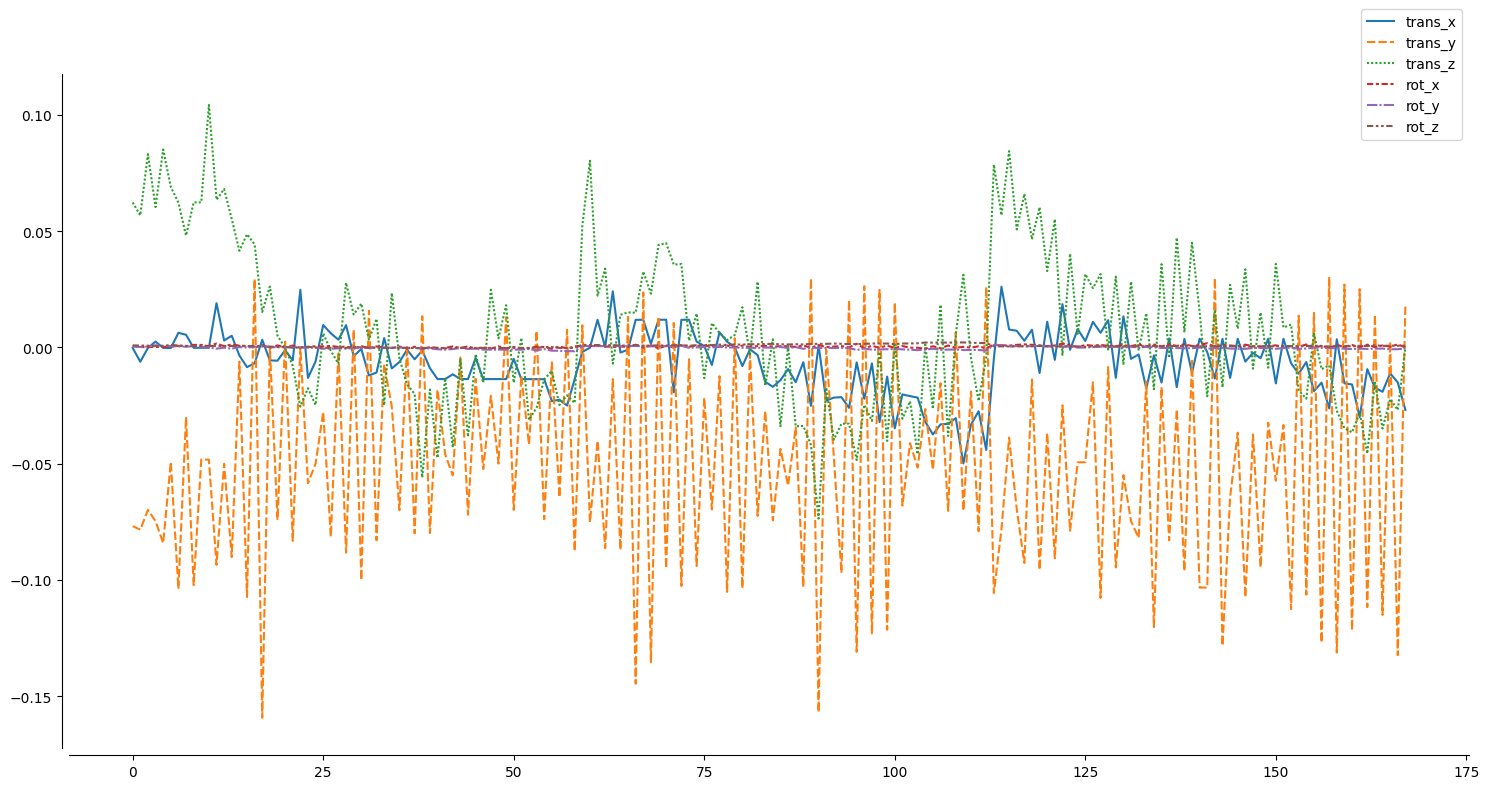

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
ax = sns.lineplot(data=confound_example[confound_example.columns[:6]])
sns.despine(offset=5)
sns.move_legend(ax, "center right", bbox_to_anchor=(1, 1))
plt.tight_layout()

With everything in-place and ready to go, we can start exploring `functional connectivity` analyzes via `nilearn`!

# 1. Extracting `times series` to build a `functional connectome`

So let's start with something "simple": Extracting `activation time series` from `regions` defined by a `parcellation`, ie `atlas`.
You might wonder: "We don't have an `atlas` yet, where do we get one and which one?". No worries at all, `nilearn` of course has your back regarding this too!


## Atlases & brain parcellations

In order to get commonly utilized and publicly available `atlases` in an accessible manner,  we can use [nilearn's great "dataset" function](https://nilearn.github.io/modules/reference.html#module-nilearn.datasets). For most `atlases`, the respective `functions` will download the `atlas` file itself, ie a `map`, and the corresponding `labels` for each of its `regions`.

How about we use the [Harvard-Oxford Atlas](https://fsl.fmrib.ox.ac.uk/fsl/docs/#/other/datasets?id=harvard-oxford-cortical-and-subcortical-structural-atlases) for our example? At first, we download the `atlas` and corresponding `data` via the [fetch_atlas_harvard_oxford](https://nilearn.github.io/modules/generated/nilearn.datasets.fetch_atlas_harvard_oxford.html#nilearn.datasets.fetch_atlas_harvard_oxford).  
Please note that we will use the default version but one can also specify the `probabilities` and `resolution`. Here, we will use a version of the `atlas` sampled at `2mm`, and with a `threshold of a probability` of `0.25`.

In [30]:
from nilearn import datasets
atlas_ho = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/fsl

Now we can access the different aspects of the `atlas` from the downloaded `dataset`:

In [32]:
atlas_ho.maps

In [33]:
atlas_ho.labels

['Background',
 'Frontal Pole',
 'Insular Cortex',
 'Superior Frontal Gyrus',
 'Middle Frontal Gyrus',
 'Inferior Frontal Gyrus, pars triangularis',
 'Inferior Frontal Gyrus, pars opercularis',
 'Precentral Gyrus',
 'Temporal Pole',
 'Superior Temporal Gyrus, anterior division',
 'Superior Temporal Gyrus, posterior division',
 'Middle Temporal Gyrus, anterior division',
 'Middle Temporal Gyrus, posterior division',
 'Middle Temporal Gyrus, temporooccipital part',
 'Inferior Temporal Gyrus, anterior division',
 'Inferior Temporal Gyrus, posterior division',
 'Inferior Temporal Gyrus, temporooccipital part',
 'Postcentral Gyrus',
 'Superior Parietal Lobule',
 'Supramarginal Gyrus, anterior division',
 'Supramarginal Gyrus, posterior division',
 'Angular Gyrus',
 'Lateral Occipital Cortex, superior division',
 'Lateral Occipital Cortex, inferior division',
 'Intracalcarine Cortex',
 'Frontal Medial Cortex',
 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
 'Subcallo

In [34]:
atlas_ho.description

".. _harvard_oxford_atlas:\n\nHarvard Oxford atlas\n====================\n\nAccess\n------\nSee :func:`nilearn.datasets.fetch_atlas_harvard_oxford`.\n\nNotes\n-----\nProbabilistic atlases covering 48 cortical and 21 subcortical structural areas,\nderived from structural data and segmentations kindly\nprovided by the Harvard Center for Morphometric Analysis.\n\nT1-weighted images of 21 healthy male and 16 healthy female subjects (ages 18-50)\nwere individually segmented by the CMA using semi-automated tools developed in-house.\nThe T1-weighted images were affine-registered to MNI152 space using FLIRT (FSL),\nand the transforms then applied to the individual labels.\nFinally, these were combined across subjects to form population probability maps for each label.\n\nFor more details: https://fsl.fmrib.ox.ac.uk/fsl/docs/#/other/datasets\n\nSee also :footcite:t:`Makris2006`, :footcite:t:`Desikan2006`,\n:footcite:t:`Frazier2005`, :footcite:t:`Goldstein2007`.\n\nContent\n-------\n    :'maps':

To get some idea how things might look like, we can also use `nilearn` for a quick `visualization`

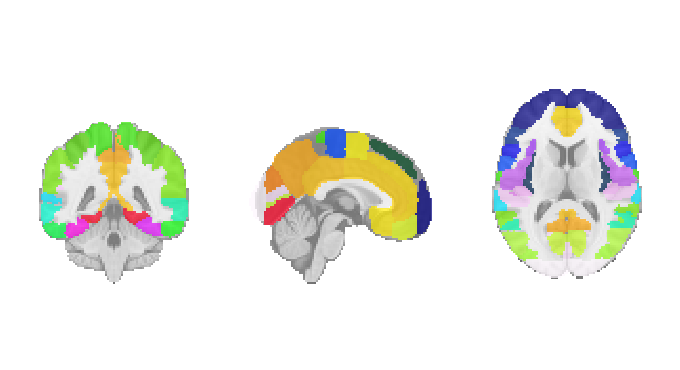

In [31]:
# Location of HarvardOxford parcellation atlas
atlas_file = atlas_ho.maps

# Visualize parcellation atlas
plotting.plot_roi(atlas_file, draw_cross=False, annotate=False);

As mentioned above, the corresponding `labels` are also part of the `dataset` and can be accessed via:

In [213]:
# Load labels for each atlas region
labels = atlas_ho.labels[1:]
labels[:10]

['Frontal Pole',
 'Insular Cortex',
 'Superior Frontal Gyrus',
 'Middle Frontal Gyrus',
 'Inferior Frontal Gyrus, pars triangularis',
 'Inferior Frontal Gyrus, pars opercularis',
 'Precentral Gyrus',
 'Temporal Pole',
 'Superior Temporal Gyrus, anterior division',
 'Superior Temporal Gyrus, posterior division']

Choosing an `atlas` or `parcellation` is one of the crucial choices one has to make when running `functional connectivity` analyzes. Depending on your use case, there might be feasible defaults and/or guidelines. However, always make sure to spend a good amount of time thinking about which one to choose (this needs a solid explanation and motivation) but rest assured that `nilearn` most likely can utilize the `atlas` of your choice or might even have it in its [datasets](https://nilearn.github.io/modules/reference.html#module-nilearn.datasets). For some pointers, make sure to have a look at [Eickhoff et al. 2018](https://www.nature.com/articles/s41583-018-0071-7).

## Extracting time-series

After having obtained the `atlas` we want to use, we can go ahead to the next step. As we want to `compute` a `functional connectome`, ie `computing` the `relationship` between `time-series` of `regions` in our `atlas`, we need to extract the `time-series` in order to subsequently apply a respective `computation`.

We already how we can easily extract `time-series` or `signals`/`data` from `images` using `nilearn` in the [nilearn intro section](https://peerherholz.github.io/workshop_IRTG2150/data_handling/image_manipulation_nilearn.html#extracting-signal-from-fmri-volumes). However, as a quick reminder: `nilearn` offers a [multitude of options](https://nilearn.github.io/stable/modules/maskers.html) and their application depends on your `data`:

- [nilearn.maskers.NiftiMasker](https://nilearn.github.io/stable/modules/generated/nilearn.maskers.NiftiMasker.html#nilearn.maskers.NiftiMasker): works well if we want to apply a single `mask` to the `data`, like a single `region of interest` (`ROI`)

- [nilearn.maskers.NiftiLabelsMasker](https://nilearn.github.io/stable/modules/generated/nilearn.maskers.NiftiLabelsMasker.html#nilearn.maskers.NiftiLabelsMasker): several `ROI`s that are `non-overlapping`, as in “hard” or `deterministic parcellations`

- [nilearn.maskers.NiftiMapsMasker](https://nilearn.github.io/stable/modules/generated/nilearn.maskers.NiftiMapsMasker.html#nilearn.maskers.NiftiMapsMasker): several `ROI`s that are maybe `overlapping`, as in “soft” or `probabilistic parcellations`


In our example, as we're using the [Harvard-Oxford Atlas ](https://fsl.fmrib.ox.ac.uk/fsl/docs/#/other/datasets?id=harvard-oxford-cortical-and-subcortical-structural-atlases), the `NiftiLabelsMasker` should be feasible. As any "maskers" in `nilearn`, it is a `processing object` that is created by specifying all the important `parameters`, but not the `data`:

In [212]:
from nilearn.input_data import NiftiLabelsMasker
masker = NiftiLabelsMasker(labels_img=atlas_file, standardize=True, verbose=1,
                           memory="nilearn_cache", memory_level=2)

The `functional image` can then be turned into a `time-series` by calling the `NiftiLabelsMasker` `fit_transform` method, that takes either `filenames` or `loaded NiftiImage objects`.

Let's do this now for the first, ie the example, `participant`. Please note, that we're providing the `confound regressors` too:

In [38]:
time_series = masker.fit_transform(development_dataset.func[0], 
                                   confounds=development_dataset.confounds[0])

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)

[NiftiLabelsMasker.wrapped] Resampling labels

[MemorizedFunc(func=<function resample_img at 0x123b53380>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/image/resampling/resample_img


________________________________________________________________________________
[Memory] Calling nilearn.image.resampling.resample_img...
resample_img(<nibabel.nifti1.Nifti1Image object at 0x12c9bda10>, interpolation='nearest', target_shape=(50, 59, 50), target_affine=array([[   4.,    0.,    0.,  -96.],
       [   0.,    4.,    0., -132.],
       [   0.,    0.,    4.,  -78.],
       [   0.,    0.,    0.,    1.]]), copy_header=True, force_resample=False)
_____________________________________________________resample_img - 0.0s, 0.0min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x12b9877d0>, { 'background_label': 0,
  'clean_kwargs': {},
  'detrend': False

[NiftiLabelsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiLabelsMasker.wrapped] Extracting region signals

________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_labels_masker.nifti_labels_masker_extractor...
nifti_labels_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12c3c8650>)
____________________________________nifti_labels_masker_extractor - 1.7s, 0.0min


[NiftiLabelsMasker.wrapped] Cleaning extracted signals

[MemorizedFunc(func=<function clean at 0x123b51300>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/signal/clean


________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[635.218164, ..., 681.952471],
       ...,
       [637.854236, ..., 687.685689]]), detrend=False, standardize=True, standardize_confounds=True, t_r=None, low_pass=None, high_pass=None, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 3.2s, 0.1min


Let's have a closer look at our `time-series`, specifically its `data type` and `shape`:

In [44]:
print("The time-series are of the type %s and have a shape of %s" %(type(time_series), str(time_series.shape)))

The time-series are of the type <class 'numpy.ndarray'> and have a shape of (168, 48)


As we can see, it's a `numpy array` with a `shape` of `(168, 48)`, that is `168 timepoints` (or `functional images`) and `48 regions` (as defind by the `atlas`). Thus, this all looks great and we can move on to the next part: `computing` the `relationship` between `time-series` of `regions` in our `atlas`.

## Compute and display the correlation matrix

With the `time-series` in place, we can simply use [nilearn's ConnectivityMeasure](https://nilearn.github.io/stable/modules/generated/nilearn.connectome.ConnectivityMeasure.html#nilearn.connectome.ConnectivityMeasure) to `compute` their `relationship`. Let's start with a classic: their `correlation`.

In [49]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([time_series])[0]

What do we get as an `output`? What should we get?

In [50]:
print("The output is of the type %s and has a shape of %s" %(type(correlation_matrix), str(correlation_matrix.shape)))

The output is of the type <class 'numpy.ndarray'> and has a shape of (48, 48)


We get a `numpy array` again and it has the `shape` `(48,48)`, that is the `correlation` of the `time-series` in `48` by `48` `regions` as defined by the `atlas`: a `correlation matrix`.

And finally, we can visualize this `correlation matrix` using [nilearn's plot_matrix](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_matrix.html#nilearn.plotting.plot_matrix), adding the `labels` for intelligibility:

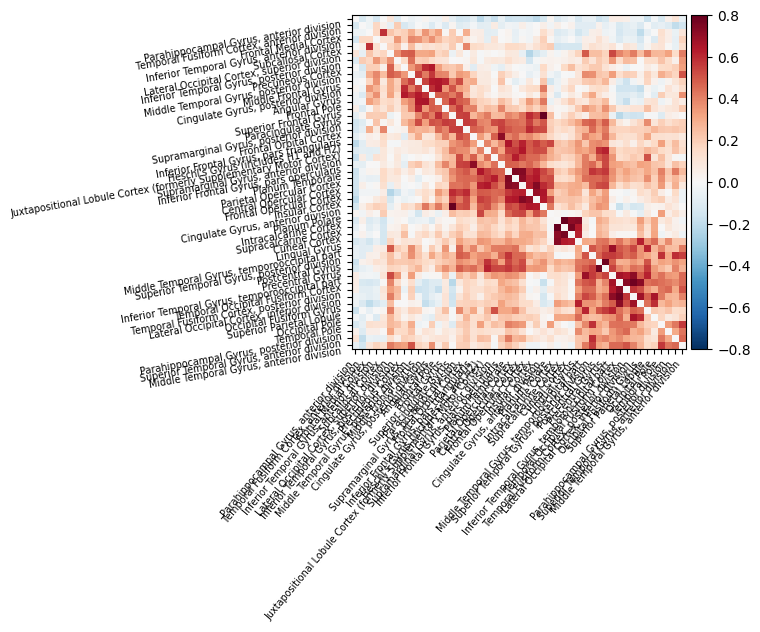

In [55]:
# Mask the main diagonal for visualization:
np.fill_diagonal(correlation_matrix, 0)

# Plot correlation matrix - note: matrix is ordered for block-like representation
plotting.plot_matrix(correlation_matrix, figure=(10, 8), labels=labels,
                     vmax=0.8, vmin=-0.8, reorder=True);

There you go, that's all it takes in terms of running `nilearn` `functions` to `compute` a `functional connectome` (leaving aside all the thinking and preparations one has to do to use the right `data` and `parameters`). It might feel like a lot as we took a longer route with explanations but it's actually only a couple of lines of `code`.

In order to showcase that and get some practice, why don't `compute` a `functional connectome` for the `2nd participant`, using the [MSDL atlas](https://nilearn.github.io/stable/modules/description/msdl_atlas.html)?

In [ ]:
## please provide your solution here

## The importance of including confounds

Let's re-run the same steps as before, but this time without using the `confounds` as we would like to stress their importance.

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x12d3619d0>, { 'background_label': 0,
  'clean_kwargs': {},
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': True,
  'labels': None,
  'labels_img': <nibabel.nifti1.Nifti1Image object at 0x12c9bda10>,
  'low_pass': None,
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': True,
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=None, sample_mask=None, dtype=None, memory=Memory(location=nilearn_cache/joblib), memory_level=2, verbose=1)


[NiftiLabelsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiLabelsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_labels_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x12d3619d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_labels_masker/nifti_labels_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_labels_masker.nifti_labels_masker_extractor...
nifti_labels_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d05e510>)
____________________________________nifti_labels_masker_extractor - 1.7s, 0.0min


[NiftiLabelsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[635.218164, ..., 681.952471],
       ...,
       [637.854236, ..., 687.685689]]), detrend=False, standardize=True, standardize_confounds=True, t_r=None, low_pass=None, high_pass=None, confounds=None, sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 3.1s, 0.1min


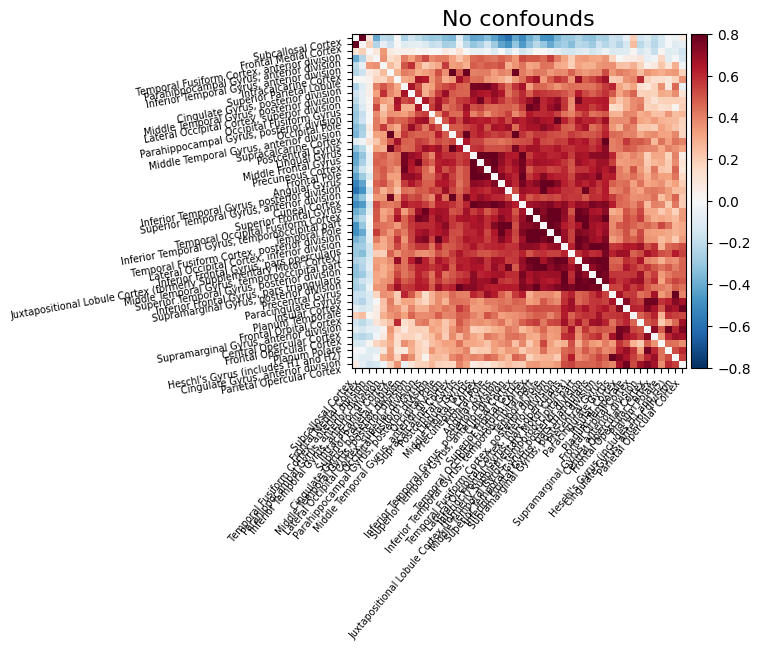

In [56]:
# Extract the signal from the regions
time_series_bad = masker.fit_transform(development_dataset.func[0]) # Note that we haven't specify confounds here

# Compute the correlation matrix
correlation_matrix_bad = correlation_measure.fit_transform([time_series_bad])[0]

# Mask the main diagonal for visualization
np.fill_diagonal(correlation_matrix_bad, 0)

# Plot the correlation matrix
plotting.plot_matrix(correlation_matrix_bad, figure=(10, 8), labels=labels,
                     vmax=0.8, vmin=-0.8, title='No confounds', reorder=True)

As you can see, without any `confounds`, basically all regions are connected to each other! One reference that discusses the importance of confounds is [Varoquaux & Craddock 2013](http://www.sciencedirect.com/science/article/pii/S1053811913003340).

### Confound strategies

If you have `pre-processed` your `data` with [fmriprep](https://fmriprep.org/en/stable/) (clear recommendation for most `datasets`), you can also benefit from the respective `data standardization` with regard to including `confounds` in your `functional connectome` pipeline.

The [load_confounds](https://nilearn.github.io/stable/modules/generated/nilearn.interfaces.fmriprep.load_confounds.html#nilearn.interfaces.fmriprep.load_confounds) function provides flexible `parameters` to retrieve the relevant `columns` from the [`TSV` file generated by fMRIPrep](https://fmriprep.org/en/stable/outputs.html#confounds).  
`load_confounds` ensures two things:

- the correct `regressors` are selected with a provided strategy, and

- `volumes` such as `non-steady-state` and/or `high motion volumes` are `masked` out correctly

Let’s try a simple strategy removing `motion`, `white matter signal`, `cerebrospinal fluid signal` with `high-pass filtering`.

In [206]:
from nilearn.interfaces.fmriprep import load_confounds

confounds_simple, sample_mask = load_confounds(
    development_dataset.func[0],
    strategy=["high_pass", "motion", "wm_csf"],
    motion="basic",
    wm_csf="basic",
)

The selected `regressors` and `computed` `mask` can now be used in the `masker` `setup`:

In [207]:
time_series = masker.fit_transform(
    development_dataset.func[0], confounds=confounds_simple, sample_mask=sample_mask
)

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x12f743e90>, { 'background_label': 0,
  'clean_kwargs': {},
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': True,
  'labels': None,
  'labels_img': <nibabel.nifti1.Nifti1Image object at 0x12c9bda10>,
  'low_pass': None,
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': True,
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=[      cosine00  cosine01  cosine02  cosine03       csf     rot_x     rot_y  \
0    0.109104  0.109090  0.10906

[NiftiLabelsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiLabelsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_labels_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x12f743e90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_labels_masker/nifti_labels_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_labels_masker.nifti_labels_masker_extractor...
nifti_labels_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x133714410>)
____________________________________nifti_labels_masker_extractor - 4.5s, 0.1min


[NiftiLabelsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[635.218164, ..., 681.952471],
       ...,
       [637.854236, ..., 687.685689]]), detrend=False, standardize=True, standardize_confounds=True, t_r=None, low_pass=None, high_pass=None, confounds=[      cosine00  cosine01  cosine02  cosine03       csf     rot_x     rot_y  \
0    0.109104  0.109090  0.109066  0.109033 -2.675004  0.000304  0.000583   
1    0.109066  0.108937  0.108723  0.108423 -2.902773 -0.000316  0.000418   
2    0.108990  0.108632  0.108038  0.107207 -2.629915 -0.000285  0.000595   
3    0.108875  0.108176  0.107012  0.105391 -1.601793 -0.000226  0.001049   
4    0.108723  0.107567  0.105651  0.102986 -2.258970 -0.000245  0.000779   
..        ...       ...       ...       ...       ...       ...       ...   
163 -0.108723  0.107567 -0.105651  0.102986  2.445759 -0.000299 -0.000335   
164 -0.108875  0.108176 -0.107012  0.105391  2.24400

As before, we can now `compute` the `correlation matrix`:

In [209]:
correlation_matrix = correlation_measure.fit_transform([time_series])[0]

and subsequentely plot it:

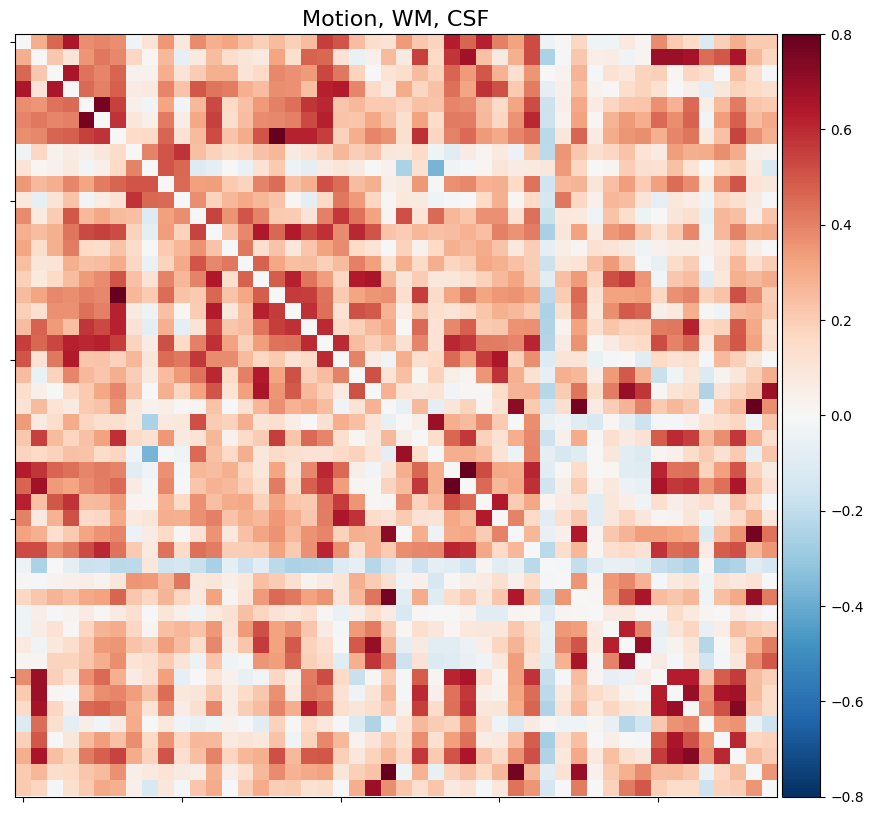

In [215]:
np.fill_diagonal(correlation_matrix, 0)

plotting.plot_matrix(
    correlation_matrix,
    figure=(10, 8),
    vmax=0.8,
    vmin=-0.8,
    title="Motion, WM, CSF",
)

Antother important aspect in `functional connectivity` analyzes is the `Global signal` or `GS`. If included as a `confound regressor`, it removes the `grand mean` from your `signal`. The benefit is that it can remove impacts of `physiological artifacts` with minimal impact on the `degrees of freedom`. The downside is that one cannot get insight into `variance explained` by certain sources of `noise`. Now let’s add `global signal` to the simple `strategy` and see its impact.

In [216]:
confounds_minimal_no_gsr, sample_mask = load_confounds(
    development_dataset.func[0],
    strategy=["high_pass", "motion", "wm_csf", "global_signal"],
    motion="basic",
    wm_csf="basic",
    global_signal="basic",
)

The remaining steps can run as before:

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)

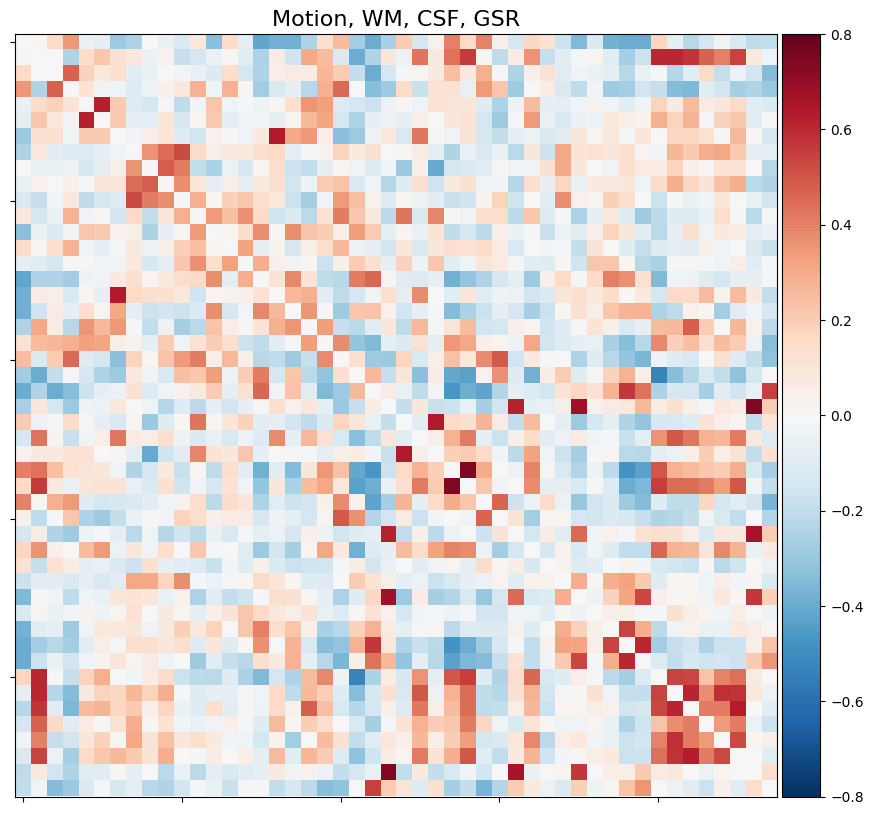

In [218]:
time_series = masker.fit_transform(
    development_dataset.func[0], confounds=confounds_minimal_no_gsr, sample_mask=sample_mask
)

correlation_matrix = correlation_measure.fit_transform([time_series])[0]

np.fill_diagonal(correlation_matrix, 0)

plotting.plot_matrix(
    correlation_matrix,
    figure=(10, 8),
    vmax=0.8,
    vmin=-0.8,
    title="Motion, WM, CSF, GSR",
)

Instead of customizing the `strategy` through `load_confounds`, one can use a `predefined strategy` with [load_confounds_strategy](https://nilearn.github.io/stable/modules/generated/nilearn.interfaces.fmriprep.load_confounds_strategy.html#nilearn.interfaces.fmriprep.load_confounds_strategy). Based on the `confound regressors` generated through `fMRIPrep`, and past benchmarks studies ([Ciric et al.](https://doi.org/10.1016/j.neuroimage.2017.03.020), [Parkes et al.](https://doi.org/10.1016/j.neuroimage.2017.12.073)): `simple`, `scrubbing`, `compcor`, `ica_aroma`. The following examples shows how to use the `simple strategy` and overwrite the `motion` default to `basic`.

In [219]:
from nilearn.interfaces.fmriprep import load_confounds_strategy

confounds, sample_mask = load_confounds_strategy(
    development_dataset.func[0], denoise_strategy="simple", motion="basic"
)

Let's see the outcome!

[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)

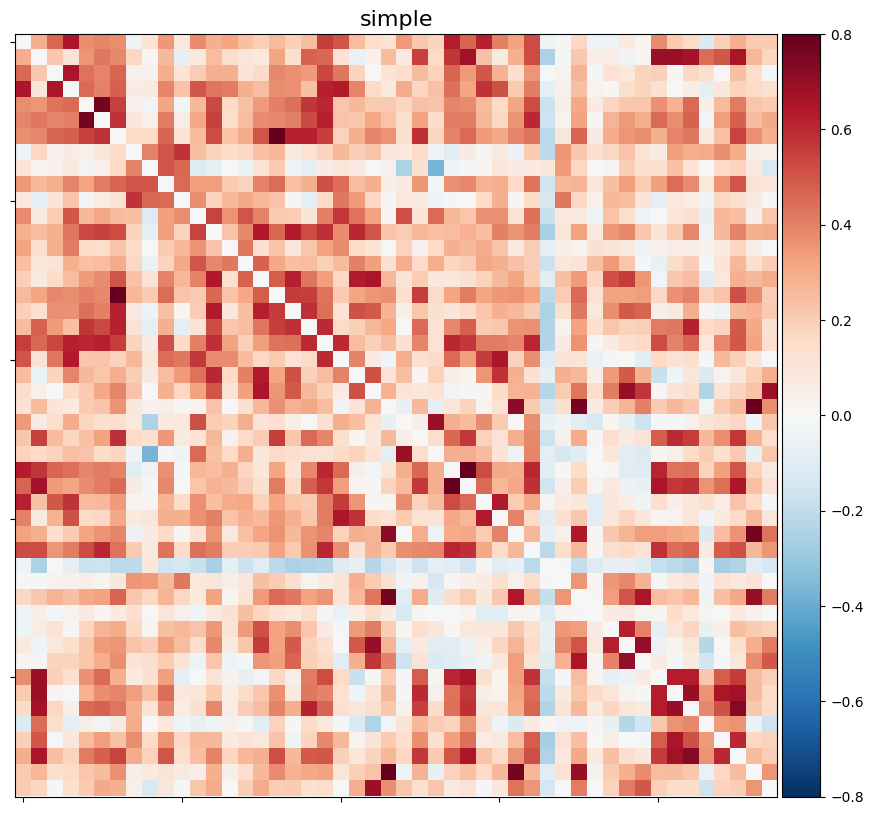

In [221]:
time_series = masker.fit_transform(
    development_dataset.func[0], confounds=confounds, sample_mask=sample_mask
)

correlation_matrix = correlation_measure.fit_transform([time_series])[0]

np.fill_diagonal(correlation_matrix, 0)

plotting.plot_matrix(
    correlation_matrix,
    figure=(10, 8),
    vmax=0.8,
    vmin=-0.8,
    title="simple",
)

Cool! In order to get some practice: could you use [load_confounds_strategy](https://nilearn.github.io/stable/modules/generated/nilearn.interfaces.fmriprep.load_confounds_strategy.html#nilearn.interfaces.fmriprep.load_confounds_strategy) again and add `global signal` back in?

In [ ]:
## please provide your solution here

## Changing parameters - atlases & maskers

To showcase how straightforward it is to adapt the `parameters` involved in `computing` a `functional connectome`, we will go through a respective example, changing the `atlas` and `masker`, including its "`behavior`". 

Starting with the `atlas`: above we used a `deterministic atlas`. Now, with `nilearn`, we can do the same steps with a `probabilistic atlas`. Let's use, for example, the [MSDL atlas](https://team.inria.fr/parietal/18-2/spatial_patterns/spatial-patterns-in-resting-state/). To outline more `nilearn functionality`, we will also focus on some dedicated parts of the `brain`, ie the `default mode network` or `DMN`.

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/msdl_atlas

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


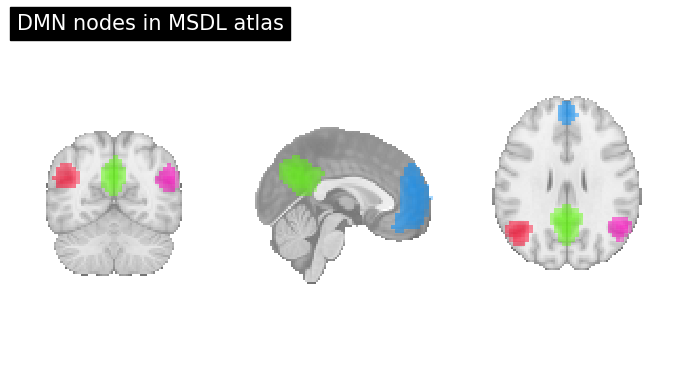

In [57]:
# Path to MSDL atlas
msdl_atlas = datasets.fetch_atlas_msdl()

# Extract only default mode network nodes
dmn_nodes = image.index_img(msdl_atlas.maps, [3, 4, 5, 6])

# Plot MSDL probability atlas
plotting.plot_prob_atlas(dmn_nodes, cut_coords=(0, -60, 29), draw_cross=False,
                         annotate=False, title="DMN nodes in MSDL atlas")

The key difference to before is that we now need to use the `NiftiMapsMasker` function to create the `masker` that extracts the `time-series` as we are utilizing a `probabilistic atlas` with (potentially) `overlapping regions`.

Additionally, we will set and/or include 

- `standardize` to `zscore_sample`: `time-series` are shifted to `zero mean` and `scaled` to `unit variance`, uses `sample std`
- `standardize_confounds`: `confounds` are `z-scored`, ie their `mean` is put to `0` and their `variance` to `1` in the `time dimension`
- `detrend` to `True`: the `time-series` will be `detrended`
- `low_pass`: low cutoff `frequency` in `Hertz`, `signals` above this `frequency` will be `filtered` out
- `high_pass`: high cutoff `frequency` in `Hertz`, `signals` below this `frequency` will be `filtered` out

In [84]:
from nilearn.input_data import NiftiMapsMasker
masker = NiftiMapsMasker(maps_img=msdl_atlas.maps, 
                         standardize="zscore_sample",
                         standardize_confounds="zscore_sample",
                         t_r=1, low_pass=0.1, high_pass=0.01,
                         detrend=True, verbose=1,
                         memory="nilearn_cache", memory_level=2)

Now, as before, we apply it to the `pre-processed` `functional images` and include the `confound regressors`:

In [85]:
# Extract the signal from the regions
time_series = masker.fit_transform(development_dataset.func[0], confounds=development_dataset.confounds[0])

[NiftiMapsMasker.wrapped] loading regions from None

[NiftiMapsMasker.wrapped] Resampling maps

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12fe72250>, { 'allow_overlap': True,
  'clean_kwargs': {},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_maps': True,
  'low_pass': 0.1,
  'maps_img': '/Users/peerherholz/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': 'zscore_sample',
  't_r': 1,
  'target_affine': None,
  'target_shape': None}, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regress

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12fe72250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f7bae90>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1883.44587 , ..., 1910.109005],
       ...,
       [1896.443682, ..., 1930.42081 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min


and then `compute` the `correlation matrix` to get the `functional connectome`:

In [86]:
# Compute the correlation matrix
correlation_matrix= correlation_measure.fit_transform([time_series])[0]

# Mask the main diagonal for visualization
np.fill_diagonal(correlation_matrix, 0)

Before we plot the new `correlation matrix`, we also need to define the `labels` of the `MSDL atlas`. At the same time we will also get the `coordinates`:

In [87]:
# CSV containing label and coordinate of MSDL atlas
msdl_labels = msdl_atlas.labels
msdl_coords = msdl_atlas.region_coords

Perfect! Now as before, we can plot the `correlation matrix` as follows:

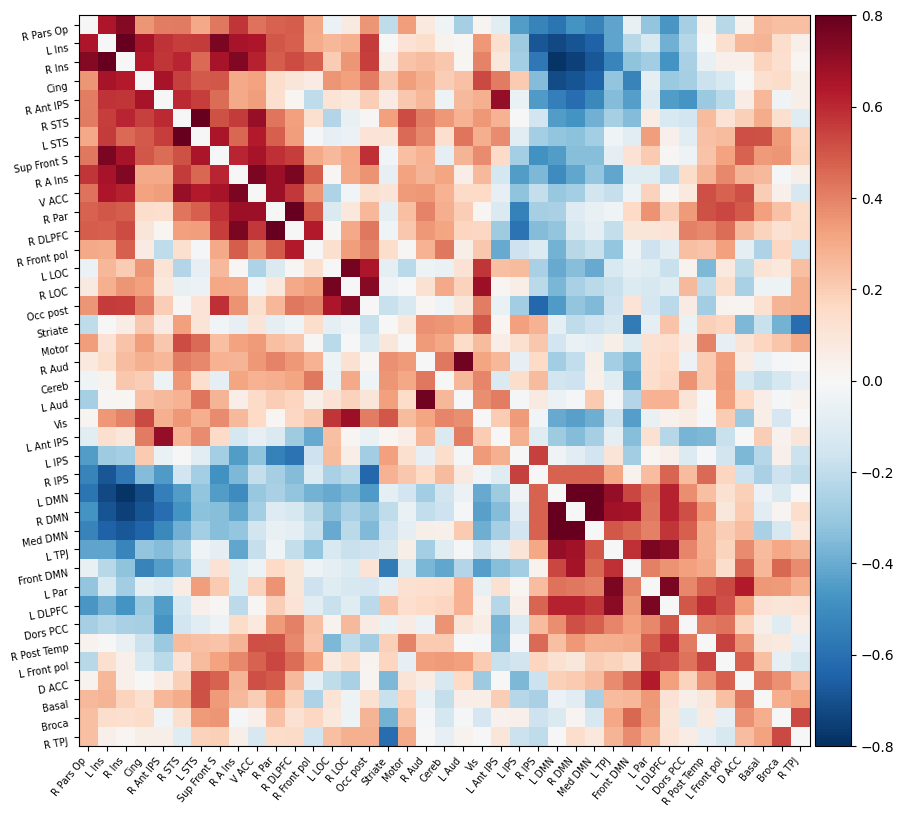

In [88]:
# Plot the correlation matrix
plotting.plot_matrix(correlation_matrix, figure=(10, 8), labels=msdl_labels,
                     vmax=0.8, vmin=-0.8, reorder=True)

This shows you how straightforward it is to change the way `time-series` are `extracted` by changing the `atlas` and `masker`. If you want to check things again, remember to get the `masker report` as outlined in the [nilearn intro section](https://peerherholz.github.io/workshop_IRTG2150/data_handling/image_manipulation_nilearn.html#extracting-signal-from-fmri-volumes).

In [68]:
report = masker.generate_report(displayed_maps=[2, 6, 7, 16, 21])
report

## Changing parameters - connectivity measures

In addition to changing the `atlas` and `extraction method`, it is also possible to change the `connectivity measure` used to `compute` the `functional connectome`. So far we used `correlation` within `ConnectivityMeasure` to `compute` the `correlation` of `ROI` `time-series`. However, `ConnectivityMeasure` supports the following options:

- `covariance`
- `correlation`
- `partial correlation`
- `tangent`

By default, ie you don't specify a measure, `ConnectivityMeasure` will use `covariance`. 

Let's have a look at the respective difference: we will `compute` the `functional connectome` with one `measure` at a time and then plot them.

In [90]:
correlation_measure_covariance = ConnectivityMeasure(kind='covariance')
correlation_matrix_covariance = correlation_measure_covariance.fit_transform([time_series])[0]

In [91]:
correlation_measure_partial_correlation = ConnectivityMeasure(kind='partial correlation')
correlation_matrix_partial_correlation = correlation_measure_partial_correlation.fit_transform([time_series])[0]

Having `computed` the `matrices`, we can now plot them side-by-side:

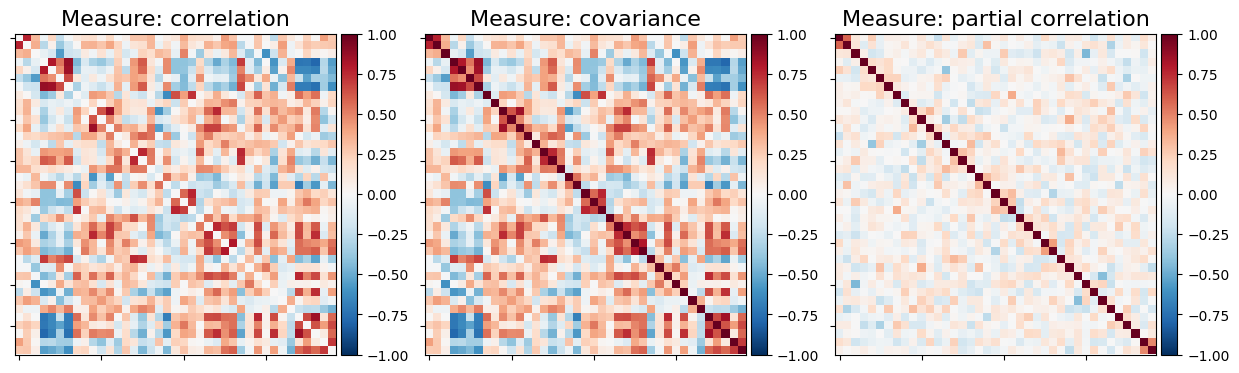

In [92]:
correlation_matrices = [correlation_matrix, correlation_matrix_covariance, correlation_matrix_partial_correlation]
correlation_measures = ['correlation', 'covariance', 'partial correlation']

_, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = np.absolute(correlation_matrices).max()
for i, (matrix, measure, ax) in enumerate(zip(correlation_matrices, correlation_measures, axes)):
    plotting.plot_matrix(
        matrix,
        colorbar=True,
        axes=ax,
        title=f"Measure: {measure}",
        vmax=vmax,
        vmin=-vmax,
    )

Now, you might ask: what's with the `tangent` `measure`? We specifically left it out before because it's a special kind of `measure`. In contrast to the other `measure`s, the `tangent space embedding` uses both `correlations` and `partial correlations` to capture reproducible `connectivity patterns` at the `group-level`.

It thus needs the `time-series` of all `participants` you would like to include. Therefore, we need to extract the `time-series` for all `participants`. Luckily, `python` and `nilearn` make this rather easy and with a little bit of `code` we can achieve not only that but also get `group-specific time-series` (remember our `dataset` has different `age groups`) which would allow us to run some `group comparisons` later.

Depending on your machine, this might take a couple of minutes.

In [93]:
children = [] # children time-series
adults = [] # adults time-series
pooled_subjects = [] # all time-series
groups = []  # child or adult

# loop over all participants, using specific images, confound regressors and demographic data
for func_file, confound_file, phenotypic in zip(development_dataset.func,
                                                development_dataset.confounds,
                                                development_dataset.phenotypic,
                                                ):
    # apply the masker to given image and confound regressor
    time_series = masker.transform(func_file, confounds=confound_file)

    # append the extracted time-series to a general list
    pooled_subjects.append(time_series)

    # append the extracted time-series to either children or adults
    if phenotypic["Child_Adult"] == "child":
        children.append(time_series)
    else:
        adults.append(time_series)

    # add group assignment of time-series to a list
    groups.append(phenotypic["Child_Adult"])

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3ca390>, { 'allow_overlap': True,
  'clean_kwargs': {},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_maps': True,
  'low_pass': 0.1,
  'maps_img': '/Users/peerherholz/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': 'zscore_sample',
  't_r': 1,
  'target_affine': None,
  'target_shape': None}, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regress

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3ca390>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12dfdb690>)
______________________________________nifti_maps_masker_extractor - 5.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

_______________________________________________filter_and_extract - 6.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12efe2250>, { 'allow_overlap': True,
  'clean_kwargs': {},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_maps': True,
  'low_pass': 0.1,
  'maps_img': '/Users/peerherholz/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': 'zscore_sample',
  'standardize_confounds': 'zscore_sample',
  't_r': 1,
  'target_affine': None,
  'target_shape': None}, confounds=[ '/Users/peerherholz/nilearn_data/develo

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12efe2250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12fcf4210>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2795.409051, ..., 2352.357519],
       ...,
       [2795.050934, ..., 2392.06787 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef022d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e84bd50>)
______________________________________nifti_maps_masker_extractor - 3.8s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2120.19077 , ..., 1937.986443],
       ...,
       [2112.749271, ..., 1920.184327]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d974b10>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50e610>)
______________________________________nifti_maps_masker_extractor - 4.0s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2123.941226, ..., 1922.398345],
       ...,
       [2120.34411 , ..., 1929.241437]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f5ad150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e767410>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2022.879917, ..., 2266.641621],
       ...,
       [2022.356191, ..., 2247.010515]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f3952d0>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2102.884087, ..., 2167.036979],
       ...,
       [2152.596335, ..., 2174.792487]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar129_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar129_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f7bbc50>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f3958d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2458.004791, ..., 2231.078955],
       ...,
       [2480.600204, ..., 2243.312897]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar129_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.9s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar130_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar130_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12dd27590>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2652.646223, ..., 2271.529008],
       ...,
       [2642.493863, ..., 2266.678143]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar130_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.7s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar131_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar131_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x13066a210>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50d210>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2169.725412, ..., 1971.713302],
       ...,
       [2207.065682, ..., 1992.208662]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar131_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar132_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar132_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3f23d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50ebd0>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2530.680838, ..., 2056.083514],
       ...,
       [2499.6674  , ..., 2045.96865 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar132_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar133_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar133_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12fe73c90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d6050>)
______________________________________nifti_maps_masker_extractor - 3.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2082.908157, ..., 2026.111137],
       ...,
       [2091.469301, ..., 2019.713476]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar133_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar134_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar134_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6a1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e6cb790>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2470.860622, ..., 2422.628537],
       ...,
       [2471.585191, ..., 2385.924495]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar134_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar135_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar135_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f34d0>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2308.552985, ..., 2624.006328],
       ...,
       [2290.411547, ..., 2676.000012]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar135_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar136_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar136_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d6050>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1997.504816, ..., 2153.319826],
       ...,
       [1983.974168, ..., 2128.3413  ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar136_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar137_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar137_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e85ac50>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f2c90>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1920.323085, ..., 1650.949659],
       ...,
       [1944.355819, ..., 1653.335092]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar137_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar138_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar138_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d5bcb10>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f3650>)
______________________________________nifti_maps_masker_extractor - 4.0s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2200.811525, ..., 2047.483635],
       ...,
       [2183.733283, ..., 2037.203364]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar138_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar139_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar139_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e527350>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2672.283091, ..., 2429.706232],
       ...,
       [2708.332696, ..., 2407.329739]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar139_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar140_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar140_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d0ed590>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50fd90>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2382.516699, ..., 1828.884295],
       ...,
       [2387.394736, ..., 1815.946145]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar140_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar141_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar141_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f0dbc90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e525050>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2024.381871, ..., 1987.598582],
       ...,
       [2025.070634, ..., 1991.478906]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar141_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar142_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar142_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c2310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433f10>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2097.603666, ..., 2110.966785],
       ...,
       [2109.87146 , ..., 2132.719561]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar142_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar143_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar143_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d66d0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2104.663339, ..., 2230.071613],
       ...,
       [2102.657682, ..., 2196.181101]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar143_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar144_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar144_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d7d5550>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e527250>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2549.17278 , ..., 2666.891801],
       ...,
       [2503.583779, ..., 2640.546365]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar144_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar145_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar145_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f5ad150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e527410>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3028.08307 , ..., 3069.515822],
       ...,
       [3010.878279, ..., 3070.142327]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar145_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar146_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar146_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ecd1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7def90>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2380.483011, ..., 2202.750818],
       ...,
       [2411.367127, ..., 2179.660092]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar146_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar147_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar147_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ff21d90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d4dd0>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2177.675435, ..., 2077.767229],
       ...,
       [2143.10868 , ..., 2046.654072]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar147_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar148_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar148_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6a1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e230350>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2266.317866, ..., 2075.392473],
       ...,
       [2264.091333, ..., 2072.148189]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar148_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar149_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar149_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125bfa990>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e408450>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2018.421494, ..., 2125.286189],
       ...,
       [2000.080772, ..., 2080.382928]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar149_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar150_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar150_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c2310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50d390>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2156.63909 , ..., 2237.968475],
       ...,
       [2166.215246, ..., 2236.684953]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar150_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar151_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar151_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50c750>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2188.87404 , ..., 2424.772378],
       ...,
       [2199.498618, ..., 2421.016094]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar151_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.3s, 0.0min
_______________________________________________filter_and_extract - 5.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar152_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar152_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12efe2250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d7990>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3263.714791, ..., 3214.862229],
       ...,
       [3297.434505, ..., 3223.134058]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar152_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar153_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar153_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e233d50>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2029.874379, ..., 1974.112529],
       ...,
       [2028.32839 , ..., 1967.708913]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar153_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar154_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar154_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c2310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50f9d0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2034.945738, ..., 1742.862226],
       ...,
       [2047.999184, ..., 1727.175601]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar154_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar155_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar155_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3d17d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e432fd0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2741.925817, ..., 2517.390649],
       ...,
       [2742.038481, ..., 2526.921065]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar155_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar001_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar001_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12dca7c90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4331d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4854.059168, ..., 4424.636052],
       ...,
       [4628.46147 , ..., 4581.877275]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar001_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar002_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar002_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4326d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4206.106746, ..., 5882.525726],
       ...,
       [4233.014976, ..., 5842.555123]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar002_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar003_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar003_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d99ab50>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3741.632528, ..., 7353.064364],
       ...,
       [3661.449275, ..., 7104.842847]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar003_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar004_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar004_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f122250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d998b10>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4777.750995, ..., 3756.286751],
       ...,
       [4795.207593, ..., 3787.656071]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar004_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar005_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar005_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef022d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e51d090>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4857.422522, ..., 5524.747709],
       ...,
       [4689.703528, ..., 5454.77267 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar005_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar006_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar006_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d7550>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3195.915757, ..., 5870.602941],
       ...,
       [3184.453698, ..., 5846.865133]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar006_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar007_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar007_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c2310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12dfda790>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4700.254702, ..., 4257.754358],
       ...,
       [4587.359068, ..., 4361.324433]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar007_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef022d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7ccf10>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[6233.34732 , ..., 5393.452052],
       ...,
       [6240.750173, ..., 5386.519359]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar008_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar009_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar009_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12df4e8d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d999c90>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3995.307307, ..., 5874.162018],
       ...,
       [4002.691377, ..., 5677.568842]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar009_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar010_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar010_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c2310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12cebe7d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4549.544988, ..., 5864.453742],
       ...,
       [4528.862478, ..., 5783.276237]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar010_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar011_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar011_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6c9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f2a10>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3970.61135 , ..., 6874.062067],
       ...,
       [3824.28157 , ..., 6916.554982]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar011_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar012_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar012_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e4323d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e767410>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3984.968678, ..., 4305.942019],
       ...,
       [4010.099632, ..., 4375.374038]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar012_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar013_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar013_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ecd1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12cebf950>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4244.084095, ..., 6179.299951],
       ...,
       [4283.771342, ..., 6218.516794]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar013_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar014_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar014_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7cc7d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3463.301925, ..., 4450.70486 ],
       ...,
       [3440.829119, ..., 4465.670436]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar014_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar015_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar015_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c1a550>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f2550>)
______________________________________nifti_maps_masker_extractor - 3.9s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3113.002523, ..., 4386.654464],
       ...,
       [3030.323572, ..., 4407.766194]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar015_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar016_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar016_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433d50>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[5239.835583, ..., 3194.005831],
       ...,
       [5403.633618, ..., 3263.839778]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar016_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.7s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar017_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar017_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f122250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433550>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4408.276597, ..., 4702.2271  ],
       ...,
       [4355.184215, ..., 4700.266751]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar017_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar018_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar018_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d7ddfd0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433f50>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[5698.023052, ..., 4416.288197],
       ...,
       [5691.89435 , ..., 4410.671542]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar018_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar019_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar019_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f122250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f017ad0>)
______________________________________nifti_maps_masker_extractor - 4.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4436.559577, ..., 3556.554752],
       ...,
       [4385.331504, ..., 3679.436028]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar019_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 5.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar020_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar020_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50d250>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3938.50283 , ..., 4180.968411],
       ...,
       [4038.588231, ..., 4293.416355]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar020_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar021_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar021_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12efdd190>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50f350>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2910.363329, ..., 4921.406291],
       ...,
       [2867.429399, ..., 5071.239154]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar021_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar022_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar022_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433590>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4208.904083, ..., 3720.887567],
       ...,
       [4313.443652, ..., 3778.145276]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar022_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar023_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar023_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125bfbc10>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f394a10>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4340.598777, ..., 3367.137222],
       ...,
       [4345.378462, ..., 3403.943843]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar023_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar024_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar024_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7dd1d0>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4606.121895, ..., 4333.859041],
       ...,
       [4676.252944, ..., 4339.046125]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar024_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar025_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar025_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3f2550>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12fcdf310>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2887.720185, ..., 5063.472743],
       ...,
       [2902.157379, ..., 5162.65956 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar025_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar026_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar026_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e836350>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2545.684774, ..., 5377.282055],
       ...,
       [2573.601701, ..., 5434.419872]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar026_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar027_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar027_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6c9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50f350>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3894.433006, ..., 3677.259636],
       ...,
       [3714.853911, ..., 3576.612119]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar027_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar028_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar028_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d99a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f121110>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3647.785028, ..., 3833.163158],
       ...,
       [3560.578837, ..., 3862.821538]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar028_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar029_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar029_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125af9d90>)
______________________________________nifti_maps_masker_extractor - 3.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4921.291265, ..., 3709.346314],
       ...,
       [5032.947353, ..., 3752.969841]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar029_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar030_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar030_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125af9d90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e765d50>)
______________________________________nifti_maps_masker_extractor - 3.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[4088.405378, ..., 4509.454687],
       ...,
       [4092.388784, ..., 4570.202922]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar030_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar031_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar031_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d99a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e428a90>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[5215.995302, ..., 4267.550109],
       ...,
       [5206.771465, ..., 4266.608742]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar031_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar032_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar032_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f015150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f0390>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2115.890668, ..., 2475.756301],
       ...,
       [2130.870175, ..., 2406.350388]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar032_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar033_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar033_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e7ed690>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e766610>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2215.313737, ..., 2305.743969],
       ...,
       [2273.424189, ..., 2320.367448]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar033_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar034_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar034_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3e3550>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2397.309504, ..., 2326.665819],
       ...,
       [2432.831632, ..., 2269.483275]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar034_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar035_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar035_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e233c10>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2248.734097, ..., 2390.590817],
       ...,
       [2260.721046, ..., 2426.517864]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar035_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar036_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar036_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f23d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2186.334438, ..., 1977.59132 ],
       ...,
       [2154.003125, ..., 1964.39399 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar036_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar037_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar037_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d4990>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2316.909278, ..., 1846.135715],
       ...,
       [2227.030203, ..., 1894.63941 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar037_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar038_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar038_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d7ddfd0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12edfc610>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2073.246394, ..., 1929.909519],
       ...,
       [2068.877685, ..., 1890.068107]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar038_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar039_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar039_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e526290>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2530.274692, ..., 2535.425691],
       ...,
       [2520.959777, ..., 2504.586056]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar039_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar040_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar040_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125b76a10>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e766610>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2155.803045, ..., 2061.426585],
       ...,
       [2167.762062, ..., 2016.477893]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar040_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar041_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar041_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d7ddfd0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e51c890>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1750.749627, ..., 2102.895557],
       ...,
       [1742.265848, ..., 2144.729262]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar041_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar042_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar042_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e8da350>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2082.57339 , ..., 1682.68796 ],
       ...,
       [2071.262674, ..., 1689.424007]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar042_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar043_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar043_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12dcc5750>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2024.619801, ..., 2291.559783],
       ...,
       [2038.14501 , ..., 2307.851987]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar043_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar044_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar044_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f015150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d6cd0>)
______________________________________nifti_maps_masker_extractor - 3.9s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2358.646069, ..., 2016.56181 ],
       ...,
       [2351.79032 , ..., 2075.001529]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar044_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.0s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar045_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar045_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7ddd50>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3382.035022, ..., 3510.743934],
       ...,
       [3338.698877, ..., 3335.575422]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar045_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar046_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar046_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e7f7310>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d4990>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2437.114025, ..., 2336.030374],
       ...,
       [2442.123175, ..., 2403.922795]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar046_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar047_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar047_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4f6950>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2205.965716, ..., 2187.075021],
       ...,
       [2203.713011, ..., 2184.209019]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar047_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar048_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar048_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x124cc2250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d74d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2433.142717, ..., 2436.974878],
       ...,
       [2438.434467, ..., 2402.336475]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar048_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.7s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar049_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar049_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7def90>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2038.920134, ..., 2097.476332],
       ...,
       [2026.569288, ..., 2110.907767]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar049_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar050_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar050_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125bcc710>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2078.447101, ..., 2075.572315],
       ...,
       [2110.463384, ..., 2015.162719]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar050_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar051_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar051_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x124cc2250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e766cd0>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2185.052927, ..., 2034.538614],
       ...,
       [2217.447027, ..., 1990.866176]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar051_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar052_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar052_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ecfbf50>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x130b28190>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2258.517667, ..., 2175.33502 ],
       ...,
       [2229.812212, ..., 2170.355817]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar052_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar053_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar053_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d999d90>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2331.134222, ..., 2309.192128],
       ...,
       [2352.965339, ..., 2288.755256]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar053_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar054_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar054_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12cebe210>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2038.722092, ..., 1924.343465],
       ...,
       [2037.73683 , ..., 1885.758074]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar054_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar055_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar055_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125b76a10>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2268.953863, ..., 2255.154537],
       ...,
       [2277.322208, ..., 2318.198292]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar055_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar056_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar056_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e837f50>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2436.375033, ..., 1784.318716],
       ...,
       [2463.075293, ..., 1804.468611]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar056_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar057_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar057_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12cebdd90>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2218.133831, ..., 2035.151665],
       ...,
       [2170.43867 , ..., 2031.73375 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar057_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar058_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar058_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12fd7ba90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f0dbc90>)
______________________________________nifti_maps_masker_extractor - 3.0s, 0.0min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2015.457979, ..., 2482.778306],
       ...,
       [2046.699592, ..., 2480.267848]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar058_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.0s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar059_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar059_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d99bc90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c24cd0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2176.079757, ..., 2521.936831],
       ...,
       [2243.025275, ..., 2522.322403]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar059_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar060_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar060_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125af86d0>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1980.458651, ..., 2127.9763  ],
       ...,
       [1977.115189, ..., 2160.779365]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar060_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar061_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar061_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e525ed0>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2409.079287, ..., 2047.924705],
       ...,
       [2451.020763, ..., 2024.693145]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar061_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar062_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar062_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12efff310>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2021.430436, ..., 1771.287951],
       ...,
       [2005.656496, ..., 1774.017472]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar062_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 5.0s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar063_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar063_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e835e90>)
______________________________________nifti_maps_masker_extractor - 5.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2267.433514, ..., 2170.730309],
       ...,
       [2265.525459, ..., 2150.058491]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar063_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
______________________________________________filter_and_extract - 11.0s, 0.2min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar064_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar064_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e837d90>)
______________________________________nifti_maps_masker_extractor - 3.9s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2378.535631, ..., 2512.003678],
       ...,
       [2390.089773, ..., 2485.649793]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar064_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar065_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar065_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d99a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7cc310>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2354.858744, ..., 2117.777022],
       ...,
       [2404.614552, ..., 2118.327145]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar065_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar066_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar066_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f5ad150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7cf110>)
______________________________________nifti_maps_masker_extractor - 6.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2134.568994, ..., 1994.624798],
       ...,
       [2125.279833, ..., 2031.015937]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar066_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 1.0s, 0.0min
_______________________________________________filter_and_extract - 8.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar067_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar067_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f74c290>)
______________________________________nifti_maps_masker_extractor - 9.5s, 0.2min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1873.528644, ..., 2035.57726 ],
       ...,
       [1871.306966, ..., 2034.861483]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar067_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
______________________________________________filter_and_extract - 11.5s, 0.2min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar068_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar068_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e84bc90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12ff22390>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2144.854361, ..., 2039.937242],
       ...,
       [2122.558422, ..., 1998.042144]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar068_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.0s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar069_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar069_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c1a550>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f395910>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2297.459441, ..., 1791.80297 ],
       ...,
       [2320.147418, ..., 1773.028462]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar069_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar070_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar070_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f3960d0>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2196.272084, ..., 2104.19233 ],
       ...,
       [2188.049384, ..., 2085.829129]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar070_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar071_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar071_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e1c36d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12dfda290>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2443.020012, ..., 2251.918955],
       ...,
       [2413.611328, ..., 2229.350945]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar071_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar072_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar072_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x1306ea2d0>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2566.239664, ..., 2426.895282],
       ...,
       [2557.830943, ..., 2419.836086]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar072_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar073_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar073_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12596ed50>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d99ae50>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2444.201667, ..., 2173.652509],
       ...,
       [2436.388564, ..., 2161.565989]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar073_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar074_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar074_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e827350>)
______________________________________nifti_maps_masker_extractor - 3.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3486.049796, ..., 2693.541287],
       ...,
       [3454.785033, ..., 2697.742415]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar074_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar075_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar075_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12fe59590>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f74c950>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1825.747574, ..., 2054.786274],
       ...,
       [1822.078939, ..., 2028.610113]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar075_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar076_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar076_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1306ea2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c519d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2112.856188, ..., 2137.169638],
       ...,
       [2111.561872, ..., 2122.288717]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar076_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar077_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar077_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f232150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f3390>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3087.021199, ..., 2901.862294],
       ...,
       [3072.436889, ..., 2881.910846]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar077_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar078_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar078_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c46210>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2253.642573, ..., 2473.662477],
       ...,
       [2232.30272 , ..., 2518.94416 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar078_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar079_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar079_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e432290>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2306.204478, ..., 2781.648027],
       ...,
       [2265.641366, ..., 2722.48746 ]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar079_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar080_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar080_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e765350>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2070.047892, ..., 2287.805714],
       ...,
       [2045.972538, ..., 2298.940635]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar080_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar081_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar081_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12dd27110>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4338d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2097.851277, ..., 1988.544606],
       ...,
       [2074.030382, ..., 2049.328907]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar081_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar082_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar082_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ecd1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f0b2190>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2105.261038, ..., 2009.046251],
       ...,
       [2103.878111, ..., 2033.270925]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar082_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar083_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar083_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e3f23d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7cfc50>)
______________________________________nifti_maps_masker_extractor - 3.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2145.012798, ..., 1775.552863],
       ...,
       [2146.445371, ..., 1798.008196]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar083_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar084_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar084_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f123c10>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2326.808153, ..., 2732.621971],
       ...,
       [2349.254138, ..., 2737.812674]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar084_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar085_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar085_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c25150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c523d0>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2659.714968, ..., 2671.658144],
       ...,
       [2687.223743, ..., 2718.660656]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar085_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar086_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar086_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x1259c2250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e51d190>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2409.25149 , ..., 1662.423413],
       ...,
       [2349.912832, ..., 1675.437115]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar086_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar087_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar087_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x13035bc10>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125b7ee50>)
______________________________________nifti_maps_masker_extractor - 3.0s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2574.496047, ..., 3055.654504],
       ...,
       [2514.73576 , ..., 3068.249769]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar087_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.0s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar088_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar088_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x130361710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50c690>)
______________________________________nifti_maps_masker_extractor - 4.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2111.648994, ..., 2017.58896 ],
       ...,
       [2128.395536, ..., 2016.229289]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar088_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar089_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar089_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef022d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3e3790>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2277.329625, ..., 2124.190386],
       ...,
       [2269.621278, ..., 2097.959032]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar089_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar090_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar090_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f36f250>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1858.02085 , ..., 2204.319976],
       ...,
       [1846.81304 , ..., 2187.016853]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar090_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.7s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar091_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar091_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f5ad150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e433c10>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2456.354267, ..., 2435.261662],
       ...,
       [2428.072384, ..., 2429.156931]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar091_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar092_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar092_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c25150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e827350>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2414.148505, ..., 2092.666088],
       ...,
       [2435.005214, ..., 2089.577737]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar092_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar093_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar093_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d4350>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3056.136979, ..., 2413.263155],
       ...,
       [3032.168134, ..., 2362.242538]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar093_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar094_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar094_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f015150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e50fdd0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2666.035642, ..., 2598.864698],
       ...,
       [2654.810312, ..., 2635.307279]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar094_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar095_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar095_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f0daa10>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2537.540615, ..., 2811.573456],
       ...,
       [2530.155085, ..., 2842.306546]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar095_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar096_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar096_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125b84c50>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2271.802751, ..., 2672.705501],
       ...,
       [2282.757007, ..., 2672.767961]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar096_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar097_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar097_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f7b9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d9ac4d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2450.222183, ..., 2510.960661],
       ...,
       [2444.833138, ..., 2477.829293]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar097_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar098_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar098_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d4310>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3904.663423, ..., 4093.926947],
       ...,
       [3859.292846, ..., 4111.785966]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar098_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.7s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar099_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar099_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c27e10>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2938.630675, ..., 2287.938343],
       ...,
       [2997.190366, ..., 2285.202387]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar099_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar100_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar100_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef7a3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f376450>)
______________________________________nifti_maps_masker_extractor - 3.8s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3831.281924, ..., 3819.167512],
       ...,
       [3871.438229, ..., 3743.985636]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar100_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar101_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar101_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c25150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7df0d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2833.273974, ..., 2434.963746],
       ...,
       [2821.087669, ..., 2410.180355]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar101_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar102_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar102_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f45b910>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e3f1950>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2620.108371, ..., 1913.830996],
       ...,
       [2703.042969, ..., 1905.869901]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar102_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar103_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar103_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e814450>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3021.520065, ..., 3043.215384],
       ...,
       [3099.929444, ..., 2968.496399]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar103_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar104_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar104_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12cebf510>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2526.616146, ..., 2197.57637 ],
       ...,
       [2490.623411, ..., 2268.469124]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar104_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar105_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar105_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c523d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4d44d0>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2079.848656, ..., 2217.882814],
       ...,
       [2259.568074, ..., 2286.985952]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar105_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.5s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar106_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar106_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7dda10>)
______________________________________nifti_maps_masker_extractor - 3.0s, 0.0min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2782.955947, ..., 2402.150254],
       ...,
       [2454.744284, ..., 2215.077291]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar106_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 3.9s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar107_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar107_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ecd1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7ce990>)
______________________________________nifti_maps_masker_extractor - 3.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2731.773702, ..., 2604.176887],
       ...,
       [2769.396703, ..., 2592.329867]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar107_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.6s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar108_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar108_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7dc810>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3228.256553, ..., 3265.073037],
       ...,
       [3235.57702 , ..., 3278.264974]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar108_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar109_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar109_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f74f690>)
______________________________________nifti_maps_masker_extractor - 3.4s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2616.281142, ..., 2540.22503 ],
       ...,
       [2622.666474, ..., 2501.996365]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar109_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.3s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar110_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar110_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x125c10d90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f0b2190>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2675.028675, ..., 2762.38866 ],
       ...,
       [2722.55098 , ..., 2673.630833]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar110_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar111_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar111_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12efce450>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12d7ddd50>)
______________________________________nifti_maps_masker_extractor - 3.6s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2182.656812, ..., 2853.777625],
       ...,
       [2120.560779, ..., 2866.604332]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar111_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.9s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar112_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar112_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6c9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f45a790>)
______________________________________nifti_maps_masker_extractor - 3.5s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2230.292641, ..., 2453.5431  ],
       ...,
       [2242.79494 , ..., 2408.557344]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar112_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 4.8s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar113_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar113_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ee8f790>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e4cfe90>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2216.057805, ..., 1854.824186],
       ...,
       [2238.820417, ..., 1862.751876]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar113_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar114_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar114_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6ea3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125c27a90>)
______________________________________nifti_maps_masker_extractor - 4.0s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2787.432503, ..., 3155.40816 ],
       ...,
       [2679.938011, ..., 3047.696836]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar114_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 5.1s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar115_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar115_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d975150>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12fcf4910>)
______________________________________nifti_maps_masker_extractor - 4.7s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[3372.397593, ..., 3695.078426],
       ...,
       [3448.790529, ..., 3700.387857]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar115_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.1s, 0.0min
_______________________________________________filter_and_extract - 6.9s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar116_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar116_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12ef022d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12ff200d0>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2110.262789, ..., 2309.166511],
       ...,
       [2102.777312, ..., 1979.608164]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar116_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar117_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar117_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12d6aa2d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125afb390>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2816.654796, ..., 2937.673435],
       ...,
       [2774.259172, ..., 2916.336842]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar117_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.4s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar118_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar118_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6da3d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12f74c290>)
______________________________________nifti_maps_masker_extractor - 4.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2663.501425, ..., 2677.19451 ],
       ...,
       [2710.222792, ..., 2747.602873]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar118_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar119_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar119_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12cf322d0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e837f10>)
______________________________________nifti_maps_masker_extractor - 4.1s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2592.845577, ..., 2506.300075],
       ...,
       [2640.539067, ..., 2532.157688]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar119_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 5.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar120_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar120_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12eeb9710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e849690>)
______________________________________nifti_maps_masker_extractor - 3.9s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2429.728153, ..., 2333.442376],
       ...,
       [2471.179093, ..., 2341.848895]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar120_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.9s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar121_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar121_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12e6a1710>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x125bb6950>)
______________________________________nifti_maps_masker_extractor - 3.2s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2003.939357, ..., 1939.00029 ],
       ...,
       [1758.482141, ..., 1865.425611]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar121_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar122_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.ma

[NiftiMapsMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar122_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMapsMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_maps_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_maps_masker._ExtractionFunctor object at 0x12f122250>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_maps_masker/nifti_maps_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_maps_masker.nifti_maps_masker_extractor...
nifti_maps_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e7cdd50>)
______________________________________nifti_maps_masker_extractor - 3.3s, 0.1min


[NiftiMapsMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[2359.470621, ..., 2526.107087],
       ...,
       [2387.390051, ..., 2448.440456]]), detrend=True, standardize='zscore_sample', standardize_confounds='zscore_sample', t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar122_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 4.2s, 0.1min


Great, now we can apply the `ConnectivityMeasure`:

In [111]:
tangent_measure_children = ConnectivityMeasure(
    kind="tangent",
    standardize="zscore_sample",
)

tangent_measure_adults = ConnectivityMeasure(
    kind="tangent",
    standardize="zscore_sample",
)

to the `time-series` of all `children` and `adults` in the `dataset`: 

In [112]:
tangent_matrices_children = tangent_measure_children.fit_transform(children)

In [113]:
tangent_matrices_adults = tangent_measure_adults.fit_transform(adults)

This outlines another interesting feature of `ConnectivityMeasure`: we can actually apply it to a `list` of `time-series` and get a `list` of `matrices` back:

In [108]:
tangent_matrices_adults.shape

(33, 39, 39)

In [106]:
tangent_matrices_adults[0]

array([[ 0.25126765,  0.09214804,  0.35305801, ..., -0.10351331,
         0.36122511,  0.25638858],
       [ 0.09214804,  0.21313428,  0.26430195, ...,  0.04157376,
         0.32216038,  0.21700367],
       [ 0.35305801,  0.26430195, -0.09623734, ..., -0.04333267,
        -0.04386978,  0.13808432],
       ...,
       [-0.10351331,  0.04157376, -0.04333267, ..., -0.54825977,
        -0.14633196,  0.01825662],
       [ 0.36122511,  0.32216038, -0.04386978, ..., -0.14633196,
         0.42905662,  0.01347542],
       [ 0.25638858,  0.21700367,  0.13808432, ...,  0.01825662,
         0.01347542, -0.03122411]])

Furthermore, the `fit`ted `ConnectivityMeasure` also stores the `mean` `matrix` across all included `participants`.

In [107]:
tangent_measure.mean_

array([[ 0.31229026,  0.22189364,  0.01785609, ..., -0.00486753,
         0.02693885, -0.00652434],
       [ 0.22189364,  0.31018004,  0.02437069, ...,  0.00201905,
        -0.00068431, -0.0220891 ],
       [ 0.01785609,  0.02437069,  0.31669954, ...,  0.00709928,
        -0.03584917, -0.03960694],
       ...,
       [-0.00486753,  0.00201905,  0.00709928, ...,  0.30864882,
         0.07536749,  0.10450625],
       [ 0.02693885, -0.00068431, -0.03584917, ...,  0.07536749,
         0.32536155,  0.22325349],
       [-0.00652434, -0.0220891 , -0.03960694, ...,  0.10450625,
         0.22325349,  0.33310447]])

Now let's visualize the `functional connectome`s for each `group`.

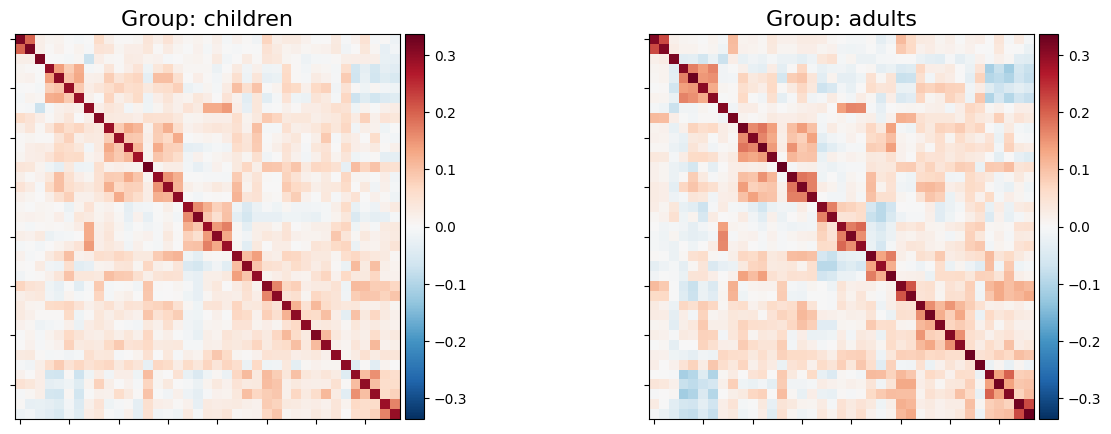

In [114]:
tangent_matrices = [tangent_measure_children.mean_, tangent_measure_adults.mean_]
groups = ['children', 'adults']

_, axes = plt.subplots(1, 2, figsize=(15, 5))
vmax = np.absolute(tangent_matrices).max()
for i, (matrix, group, ax) in enumerate(zip(tangent_matrices, groups, axes)):
    plotting.plot_matrix(
        matrix,
        colorbar=True,
        axes=ax,
        title=f"Group: {group}",
        vmax=vmax,
        vmin=-vmax,
    )

While it's great that one can easily employ all these different options, it's important to remember that the specific implementation, ie all `parameters`, depend on the `dataset` at hand and the respectively planned analyzes. Thus, please make sure to evaluate your options before running the corresponding steps!

## Statistical analyzes and Outputs 

Having obtained all different kinds of `functional connectome`s, you could run further `analyzes`, specifically `statistics`, depending on the given question/hypothesis. As the `functional connectome`s are `numpy arrays`, you could make use of the amazing integration across packages a lot of the `python` ecosystem offers. For example, you could create `dataframes` of your `functional connectome`s using [pandas](https://pandas.pydata.org/pandas-docs/stable/index.html) and then run `statistical tests` using [statsmodels](https://www.statsmodels.org/stable/index.html) or [pingouin](https://pingouin-stats.org/build/html/index.html) and finally, `visualize` the results via [matplotlib](https://matplotlib.org/stable/index.html) and/or [seaborn](https://seaborn.pydata.org/index.html).

Independent of that, it might be a good idea to save the `computed` `functional connectomes` to files so that you don't have to `compute` them over and over again but have them ready to go!

In [116]:
correlation_measure = ConnectivityMeasure(kind="correlation",
                                         standardize="zscore_sample",
                                        )

correlation_matrices = correlation_measure.fit_transform(pooled_subjects)

np.savez_compressed('data/development_fmri_correlation_matrix', correlation_matrices = correlation_matrices)

In [117]:
covariance_measure = ConnectivityMeasure(kind="covariance",
                                         standardize="zscore_sample",
                                        )

covariance_matrices = covariance_measure.fit_transform(pooled_subjects)

np.savez_compressed('data/development_fmri_covariance_matrix', covariance_matrices = covariance_matrices)

In [118]:
partial_correlation_measure = ConnectivityMeasure(kind="partial correlation",
                                         standardize="zscore_sample",
                                        )

partial_correlation_matrices = partial_correlation_measure.fit_transform(pooled_subjects)

np.savez_compressed('data/development_fmri_partial_correlation_matrix', partial_correlation_matrices = partial_correlation_matrices)

In [119]:
tangent_measure = ConnectivityMeasure(kind="tangent",
                                         standardize="zscore_sample",
                                        )

tangent_matrices = tangent_measure.fit_transform(pooled_subjects)

np.savez_compressed('data/development_fmri_tangent_matrix', tangent_matrices = tangent_matrices)

## Display corresponding graph on glass brain

As a little add-on, we also want to show you different `visualization` options beyond a `matrix`.

A `matrix`, such as a `functional connectome`, can also be seen as a "`graph`": a set of "`nodes`", connected by "`edges`". When these `nodes` are `brain regions`, and the `edges` capture `interactions` between them, this graph is a "`functional connectome`".

As the `MSDL atlas` comes with (`x`, `y`, `z`) `MNI coordinates` for the different `regions`, we can `visualize` the `matrix` as a `graph` of `interactions` in a `brain`via [nilearn's plot_connectome](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_connectome.html#nilearn.plotting.plot_connectome). To avoid having too dense a `graph`, we represent only the `20% edges` with the highest `values`. 

NB: For other `atlas`es without `coordinates`, the needed information can be `computed` for each `region` with the [`nilearn.plotting.find_xyz_cut_coords` function](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.find_xyz_cut_coords.html#nilearn.plotting.find_xyz_cut_coords):

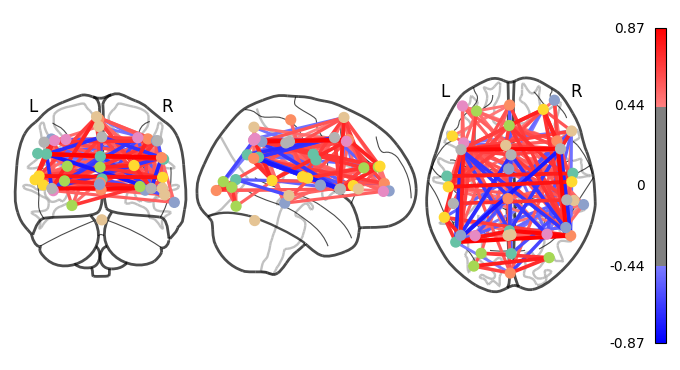

In [120]:
plotting.plot_connectome(correlation_matrix, msdl_coords, edge_threshold="80%",
                         colorbar=True)

As you can see, the `correlation matrix` gives a very "full" `graph`: almost every `node` is connected to every other one. This is because it also captures indirect `connections`.

From version `0.5.0` on, `nilearn` also provides an `interactive plot` for `connectoms` via [view_connectome](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.view_connectome.html#nilearn.plotting.view_connectome):

In [121]:
plotting.view_connectome(correlation_matrix, msdl_coords, edge_threshold="80%", edge_cmap='bwr',
                         symmetric_cmap=True, linewidth=6.0, node_size=3.0)

That concludes the rather lengthy overview section on building `functional connectomes`. However, `nilearn` has a lot more functionality when it comes to `functional connectivity`. So we will spend a bit more time exploring them respectively.

# 2. Single subject maps of seed-to-voxel correlation

Above we `computed` `functional connectomes` based on `atlases`, ie `interactions` between different regions or `ROIs` as defined by an `atlas`. But what if we want to compute a `seed-to-voxel correlation map`, ie a `map` providing information on how the signal of an `ROI` is correlated with the rest of the `brain` over time? The corresponding procedure is actually very similar to the one from before. We have to start with ...

## Time series extraction

First, we need to `extract` the `time-series` from the `seed region`, ie our `ROI`. For this example, we could specify a sphere with a radius of `8` (in `mm`) located in the `Posterior Cingulate Cortex` as indicated by a `x`, `y` and `z` `coordinate`. 

Please note, that you could also use an `ROI` as defined by an `atlas` or a respective `binary` `mask`.

In [122]:
# Sphere radius in mm
sphere_radius = 8

# Sphere center in MNI-coordinate
sphere_coords = [(0, -52, 18)]

In this case, we will use the `NiftiSpheresMasker` to `extract` the `time-series` within a given `sphere`. During that, we can also directly `detrend`, `standardize`, and `bandpass filter` the `data` as seen before.

In [135]:
from nilearn.input_data import NiftiSpheresMasker
seed_masker = NiftiSpheresMasker(sphere_coords, radius=sphere_radius, detrend=True,
                                 standardize=True, low_pass=0.1, high_pass=0.01,
                                 t_r=1, verbose=1, memory="nilearn_cache", memory_level=2)

Now we're ready to extract the `mean` `time-series` within the `seed region` or `ROI`, while also `regressing` out the `confounds`.

In [136]:
seed_time_series = seed_masker.fit_transform(development_dataset.func[0], confounds=development_dataset.confounds[0])

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_spheres_masker._ExtractionFunctor object at 0x131560d90>, { 'allow_overlap': False,
  'clean_kwargs': {},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'low_pass': 0.1,
  'mask_img': None,
  'radius': 8,
  'reports': True,
  'seeds': [(0, -52, 18)],
  'smoothing_fwhm': None,
  'standardize': True,
  'standardize_confounds': True,
  't_r': 1}, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, dtype=None, memory=Memory(location=nilearn_cache/joblib), memory_level=2, verbose=1)


[NiftiSpheresMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiSpheresMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_spheres_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_spheres_masker._ExtractionFunctor object at 0x131560d90>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_spheres_masker/nifti_spheres_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_spheres_masker.nifti_spheres_masker_extractor...
nifti_spheres_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x12e764310>)
___________________________________nifti_spheres_masker_extractor - 4.5s, 0.1min


[NiftiSpheresMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[409.664116],
       ...,
       [410.364373]]), detrend=True, standardize=True, standardize_confounds=True, t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 6.2s, 0.1min


Next, we need to do a similar procedure for each `voxel` in the `brain` as well. For this, we can use the `NiftiMasker`, with the same `arguments` as before, plus additionally `smoothing` the `signal` with a `smoothing kernel` of `6mm`.

In [138]:
from nilearn.input_data import NiftiMasker
brain_masker = NiftiMasker(smoothing_fwhm=6, detrend=True, standardize=True,
                           low_pass=0.1, high_pass=0.01, t_r=1, verbose=1,
                           memory="nilearn_cache", memory_level=2)

Now we can `extract` the `time-series` for every `voxel` while `regressing` out the `confounds`:

In [139]:
brain_time_series = brain_masker.fit_transform(development_dataset.func[0], confounds=development_dataset.confounds[0])

[NiftiMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiMasker.wrapped] Computing the mask

[NiftiMasker.wrapped] Resampling mask

[NiftiMasker.wrapped] Finished fit

________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_masker._filter_and_mask...
_filter_and_mask('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nibabel.nifti1.Nifti1Image object at 0x131ac7050>, { 'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'low_pass': 0.1,
  'reports': True,
  'runs': None,
  'smoothing_fwhm': 6,
  'standardize': True,
  'standardize_confounds': True,
  't_r': 1,
  'target_affine': None,
  'target_shape': None}, memory_level=2, memory=Memory(location=nilearn_cache/joblib), verbose=1, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, copy=True, dtype=None)


[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152
NLin2009cAsym_desc-preproc_bold.nii.gz')

[NiftiMasker.wrapped] Smoothing images

[NiftiMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_masker._ExtractionFunctor object at 0x125c5cbd0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_masker/nifti_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_masker.nifti_masker_extractor...
nifti_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x130d56f90>)
___________________________________________nifti_masker_extractor - 1.6s, 0.0min


[NiftiMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[ 1.810116, ..., -1.214456],
       ...,
       [ 1.578021, ..., -1.218449]]), detrend=True, standardize=True, standardize_confounds=True, t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
___________________________________________________________clean - 15.2s, 0.3min
_________________________________________________filter_and_mask - 18.4s, 0.3min


## Performing the seed-based correlation analysis

Having two `arrays` now (`mean signal` in `seed region`/`ROI` and `signal` for each `voxel`), we can `correlate` the two. This can be done with the [dot product](https://en.wikipedia.org/wiki/Dot_product) (e.g. via [`numpy's dot` `function`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)) between the two `arrays`.

**Note**, that the signals have been `variance-standardized` during `extraction`. To have them `standardized` to
`norm unit`, we further have to `divide` the result by the `length` of the `time-series`.

In [140]:
seed_based_correlations = np.dot(brain_time_series.T, seed_time_series)
seed_based_correlations /= seed_time_series.shape[0]

## Plotting the seed-based correlation map

Finally, we can `transform` the `correlation array` back to a `Nifti image` via `inverse_transform`. 

In [141]:
seed_based_correlation_img = brain_masker.inverse_transform(seed_based_correlations.T)

________________________________________________________________________________
[Memory] Calling nilearn.masking.unmask...
unmask(array([[0.362534, ..., 0.257144]]), <nibabel.nifti1.Nifti1Image object at 0x131ac7050>)
___________________________________________________________unmask - 0.9s, 0.0min


and then `plot` the resulting `seed-to-voxel correlation map` to better investigate outcome:

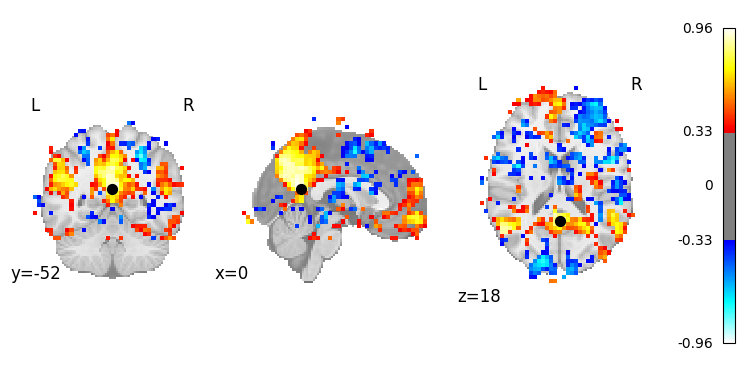

In [142]:
# plot the seed-to-voxel correlation map
display = plotting.plot_stat_map(seed_based_correlation_img, threshold=0.333,
                                 cut_coords=sphere_coords[0], draw_cross=False)

# add a marker to display the seed region/ROI
display.add_markers(marker_coords=sphere_coords, marker_color='black',
                    marker_size=50)

To summarize: the `map` above depicts the `temporal correlation` of a **seed region** with the **rest of the brain**. For a similar example but on the `cortical surface`, see [this example](http://nilearn.github.io/auto_examples/01_plotting/plot_surf_stat_map.html#seed-based-connectivity-on-the-surface).

# 3. Single subject maps of seed-to-seed correlation

Another potential question is, of course, how can we `compute` the `correlation` between different `seed regions`/`ROI`s?  It's actually very easy, even simpler than above. It all starts with our old friend ...

## Time series extraction

First, we need to `extract` the `time-series` from the `seed regions`/`ROI`s. So, as before, we demonstrate this via `spheres` but please remember that this could also be `regions`/`ROI`s from an `atlas` or `binary masks`.

In [143]:
# Sphere radius in mm
sphere_radius = 8

# Sphere centers in MNI-coordinate as a list
sphere_center = [(  0, -52, 18),
                 (-46, -68, 32),
                 ( 46, -68, 32),
                 (  1,  50, -5)]

Now we can `extract` the `time-series` from those `spheres`:

In [144]:
# Create masker object to extract average signal within spheres
from nilearn.input_data import NiftiSpheresMasker
masker = NiftiSpheresMasker(sphere_center, radius=sphere_radius, detrend=True,
                            standardize=True, low_pass=0.1, high_pass=0.01,
                            t_r=1, verbose=1, memory="nilearn_cache", memory_level=2)

In [147]:
# Extract average signal in spheres with masker object
time_series = masker.fit_transform(development_dataset.func[0], confounds=development_dataset.confounds[0])

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker._filter_and_extract...
_filter_and_extract('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz', 
<nilearn.maskers.nifti_spheres_masker._ExtractionFunctor object at 0x12f120cd0>, { 'allow_overlap': False,
  'clean_kwargs': {},
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'low_pass': 0.1,
  'mask_img': None,
  'radius': 8,
  'reports': True,
  'seeds': [(0, -52, 18), (-46, -68, 32), (46, -68, 32), (1, 50, -5)],
  'smoothing_fwhm': None,
  'standardize': True,
  'standardize_confounds': True,
  't_r': 1}, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, dtype=None, memory=Memory(location=nilearn_cache/joblib), memory

[NiftiSpheresMasker.wrapped] Loading data from 
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym
_desc-preproc_bold.nii.gz

[NiftiSpheresMasker.wrapped] Extracting region signals

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:577: JobLibCollisionWarning: Cannot detect name collisions for function 'nifti_spheres_masker_extractor'
  return self._cached_call(args, kwargs, shelving=False)[0]
[MemorizedFunc(func=<nilearn.maskers.nifti_spheres_masker._ExtractionFunctor object at 0x12f120cd0>, location=nilearn_cache/joblib)]: Clearing function cache identified by nilearn/maskers/nifti_spheres_masker/nifti_spheres_masker_extractor


________________________________________________________________________________
[Memory] Calling nilearn.maskers.nifti_spheres_masker.nifti_spheres_masker_extractor...
nifti_spheres_masker_extractor(<nibabel.nifti1.Nifti1Image object at 0x131f52e90>)
___________________________________nifti_spheres_masker_extractor - 4.0s, 0.1min


[NiftiSpheresMasker.wrapped] Cleaning extracted signals

________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[409.664116, ..., 673.587157],
       ...,
       [410.364373, ..., 673.739187]]), detrend=True, standardize=True, standardize_confounds=True, t_r=1, low_pass=0.1, high_pass=0.01, confounds=[ '/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'], sample_mask=None, runs=None)
____________________________________________________________clean - 0.0s, 0.0min
_______________________________________________filter_and_extract - 6.7s, 0.1min


## Display mean signal per sphere

If we want, we can even plot the average signal per sphere:

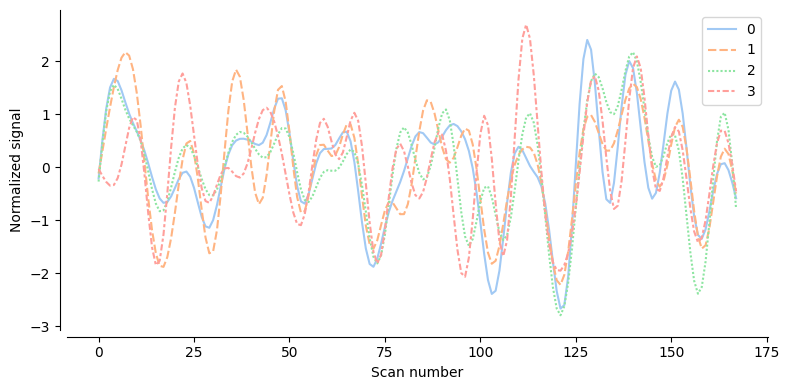

In [152]:
fig = plt.figure(figsize=(8, 4))
sns.lineplot(time_series, palette='pastel')
plt.xlabel('Scan number')
plt.ylabel('Normalized signal')
sns.despine(offset=5)
plt.tight_layout();

## Compute partial correlation matrix

Now that we have the `average` `signal` per `sphere` we can `compute` the `partial correlation` between them, using the `ConnectivityMeasure` function again.

In [153]:
from nilearn.connectome import ConnectivityMeasure
connectivity_measure = ConnectivityMeasure(kind='partial correlation')
partial_correlation_matrix = connectivity_measure.fit_transform([time_series])[0]

That's all it takes and we can already plot the resulting `matrix`. Here, we will use a different plotting approach to show you the versatility.

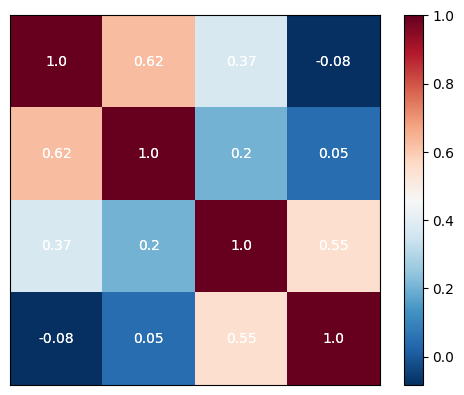

In [160]:
fig, ax = plt.subplots()
plt.imshow(partial_correlation_matrix, cmap='RdBu_r', )
for (j,i),label in np.ndenumerate(partial_correlation_matrix):
    ax.text(i, j, round(label, 2), ha='center', va='center', color='w')
    ax.text(i, j, round(label, 2), ha='center', va='center', color='w')
ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])
plt.colorbar()

## Displaying the connectome as a graph

Now that we have the `partial correlation matrix`, we can also plot it again as a `graph` with `plot_connectome`:

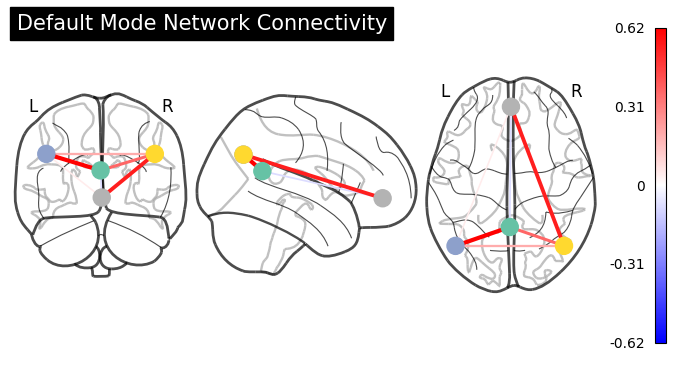

In [161]:
from nilearn.plotting import plot_connectome
plot_connectome(partial_correlation_matrix, sphere_center,
                display_mode='ortho', colorbar=True,  node_size=150,
                title="Default Mode Network Connectivity")

And again with `nilearn`'s `interactive` [`view_connectome` function](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.view_connectome.html#nilearn.plotting.view_connectome):

In [162]:
plotting.view_connectome(partial_correlation_matrix, sphere_center, edge_cmap='bwr',
                         symmetric_cmap=True, linewidth=6.0, node_size=10.0)

# 4. Extracting `brain networks` in a `data-driven` way

In the last section, we want to `demonstrate` another important analyzes approach: extracting `brain networks` in a `data-driven` way. 
There are many different options to do this but we will have a look at a few commonly applied ones, showcasing how you can employ them using `nilearn`.

## Multi-subject ICA: CanICA

At first, we will check `multi-subject Independent Component Analysis` (`ICA`), speficially the `CanICA` approach. It implements a `multivariate random effects model` across `participants`. 

`CanICA` is a ready-to-use object that can be applied to `multi-participant` `Nifti data`, for instance, presented as `filenames`, and will perform a `multi-participant` `ICA` `decomposition` following the `CanICA` model.

In [177]:
from nilearn.decomposition import CanICA

canica = CanICA(
                n_components=20,
                memory="nilearn_cache",
                memory_level=2,
                verbose=10,
                mask_strategy="whole-brain-template",
                random_state=0,
                standardize="zscore_sample",
                n_jobs=2,
)

As with every object in `nilearn`, we give its `parameters` at `setup`, and then `fit` it on the `data`. As this is a quite heavy `computation`, we will only use roughly half of the dataset for time-purposes.

In [178]:
canica.fit(development_dataset.func[:50])

[CanICA.fit] Loading data from 
[/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar129_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar130_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar131_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar132_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar133_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar134_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar135_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar136_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar137_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar138_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar139_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar140_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar141_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar142_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar143_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar144_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar145_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar146_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar147_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar148_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar149_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar150_

[CanICA.fit] Computing the mask

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:616: UserWarning: Cannot inspect object functools.partial(<function compute_brain_mask at 0x124d385e0>, mask_type='whole-brain'), ignore list will not work.
  return hashing.hash(filter_args(self.func, self.ignore, args, kwargs),


[CanICA.fit] Template whole-brain mask computation

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:813: UserWarning: Cannot inspect object functools.partial(<function compute_brain_mask at 0x124d385e0>, mask_type='whole-brain'), ignore list will not work.
  argument_dict = filter_args(self.func, self.ignore,


[CanICA.fit] Resampling mask

[CanICA.fit] Finished fit

[CanICA.fit] Loading data

python(93699) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93700) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Smoothing images
[NiftiMasker.wrapped] Smoothing images
[NiftiMasker.wrapped] Extracting region signals
[NiftiMasker.wrapped] Extracting region signals
[NiftiMasker.wrapped] Cleaning extracted signals
[NiftiMasker.wrapped] Cleaning extracted signals
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Smoothing images
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/developme

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    2.3s
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed:    6.6s finished
/var/folders/61/0lj9r7px3k52gv9yfyx6ky300000gn/T/ipykernel_6711/3702690714.py:1: FutureWarning: The nifti_maps_masker_ attribute is deprecated andwill be removed in Nilearn 0.11.3. Please use maps_masker_ instead.
  canica.fit(development_dataset.func[:50])


CanICA(mask_strategy='whole-brain-template',
       memory=Memory(location=nilearn_cache/joblib), memory_level=2, n_jobs=2,
       random_state=0, standardize='zscore_sample', verbose=10)

Once `CanICA` has finished we can retrieve the computed `independent components` directly as `images` in the same space as the `input`.

In [179]:
components_img = canica.components_img_

The resulting `image` is a `4D image` with obtained `components` (`n=20`) in the `spatial dimensions` of the `input`, stacked across the `4th dimension`.

In [180]:
components_img.shape

(50, 59, 50, 20)

## Visualizing CanICA components

To `visualize` the `components` we can `plot` the `outline` of all of them in one `figure`.

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


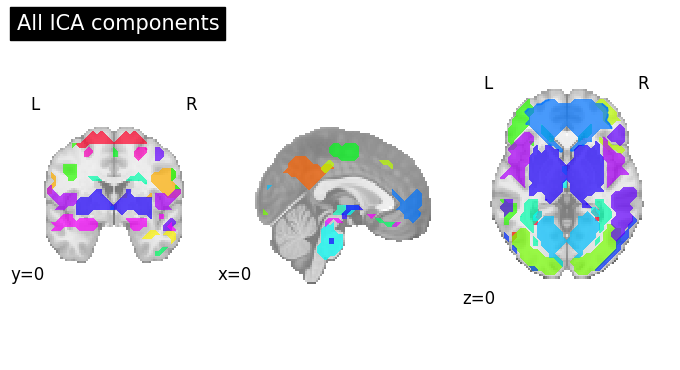

In [181]:
# Plot all ICA components together
plotting.plot_prob_atlas(components_img, draw_cross=False, linewidths=None,
                         cut_coords=[0, 0, 0], title='All ICA components');

If you would like to get a better look at each `component`, we can of course also `plot` them separately using the `plot_stat_map` and `iter_img` functions. Let's have a look at them:

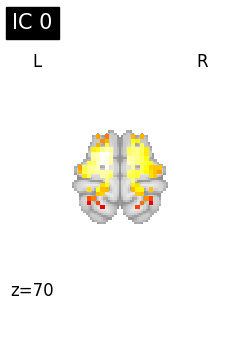

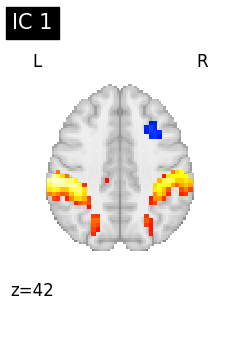

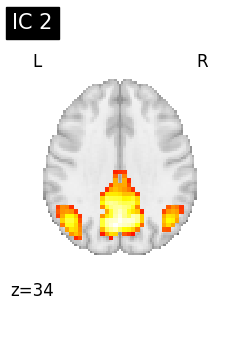

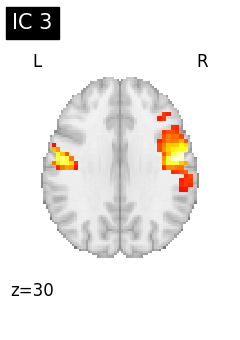

In [198]:
from nilearn.image import iter_img
from nilearn.plotting import plot_stat_map, show

for i, cur_img in enumerate(iter_img(components_img.slicer[..., :4])):
    plot_stat_map(
        cur_img,
        display_mode="z",
        title=f"IC {int(i)}",
        cut_coords=1,
        colorbar=False,
    )

That's the basic workflow. Depending on your planned `analyzes`, you could evaluate the `components` further, compare them across `groups`, use them to `extract` `time-series` of other `data` and much more. 

As mentioned before, `nilearn` offers more `decomposition` methods. In the following, we will briefly explore another one.

## Beyond ICA : Dictionary learning

`Dictionary learning` is a `sparsity-based decomposition` method for extracting `spatial maps`. It extracts `maps` that are naturally `sparse` and usually cleaner than `ICA`. Recent work has shown that `dictionary learning` based techniques outperform `ICA` in term of stability and constitutes a better first step in a `statistical analysis pipeline`. `Dictionary learning` in neuroimaging seeks to extract a few representative temporal elements along with their `sparse spatial loadings`.

So let's do the same thing again as above, but this time with `DictLearning`.

In [184]:
# Import dictionary learning algorithm
from nilearn.decomposition import DictLearning

In [185]:
dict_learning = DictLearning(
                            n_components=20,
                            memory="nilearn_cache",
                            memory_level=2,
                            verbose=1,
                            random_state=0,
                            n_epochs=1,
                            mask_strategy="whole-brain-template",
                            standardize="zscore_sample",
                            n_jobs=2,
)

Now we're ready and can apply the `dictionary learning` `object` on the `functional data`. As before, we will only use roughly half of the `dataset` for time reasons:

In [187]:
# Fit to the data
dict_learning.fit(development_dataset.func[:50])

[DictLearning.fit] Loading data from 
[/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar129_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar130_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar131_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar132_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar133_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar134_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar135_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar136_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar137_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar138_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar139_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar140_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar141_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar142_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar143_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar144_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar145_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar146_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar147_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar148_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar149_task-pixar_space-MNI152NLin2009cAsy
m_desc-preproc_bold.nii.gz,
 /Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pix

[DictLearning.fit] Computing the mask

/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:616: UserWarning: Cannot inspect object functools.partial(<function compute_brain_mask at 0x124d385e0>, mask_type='whole-brain'), ignore list will not work.
  return hashing.hash(filter_args(self.func, self.ignore, args, kwargs),
/Users/peerherholz/anaconda3/envs/workshop_IRTG2150/lib/python3.11/site-packages/joblib/memory.py:813: UserWarning: Cannot inspect object functools.partial(<function compute_brain_mask at 0x124d385e0>, mask_type='whole-brain'), ignore list will not work.
  argument_dict = filter_args(self.func, self.ignore,


[DictLearning.fit] Resampling mask

[DictLearning.fit] Finished fit

[DictLearning.fit] Loading data

python(38252) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(38253) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Smoothing images
[NiftiMasker.wrapped] Smoothing images
[NiftiMasker.wrapped] Extracting region signals
[NiftiMasker.wrapped] Extracting region signals
[NiftiMasker.wrapped] Cleaning extracted signals
[NiftiMasker.wrapped] Cleaning extracted signals
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
[NiftiMasker.wrapped] Loading data from 
Nifti1Image('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/s
ub-pixar126_

[DictLearning.fit] Learning initial components

________________________________________________________________________________
[Memory] Calling sklearn.utils.extmath.randomized_svd...
randomized_svd(array([[-0.001315, ..., -0.010262],
       ...,
       [ 0.011243, ..., -0.011141]]), n_components=20, transpose=True, random_state=0, n_iter=3)
___________________________________________________randomized_svd - 1.3s, 0.0min


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[DictLearning.fit] Computing initial loadings

________________________________________________________________________________
[Memory] Calling nilearn.decomposition.dict_learning._compute_loadings...
_compute_loadings(array([[ 0.004812, ..., -0.001545],
       ...,
       [-0.002872, ..., -0.000921]]), 
array([[-0.622651, ...,  5.322742],
       ...,
       [-1.797278, ..., -1.951271]]))
_________________________________________________compute_loadings - 0.3s, 0.0min


[DictLearning.fit]  Learning dictionary

________________________________________________________________________________
[Memory] Calling sklearn.decomposition._dict_learning.dict_learning_online...
dict_learning_online(array([[-0.622651, ..., -1.797278],
       ...,
       [ 5.322742, ..., -1.951271]]), 
20, alpha=10, batch_size=20, method='cd', dict_init=array([[ 0.472253, ...,  0.026948],
       ...,
       [ 0.397073, ..., -0.003254]]), verbose=0, random_state=0, return_code=True, shuffle=True, n_jobs=1, max_iter=1090)
_____________________________________________dict_learning_online - 5.0s, 0.1min


/var/folders/61/0lj9r7px3k52gv9yfyx6ky300000gn/T/ipykernel_6711/1181013639.py:2: FutureWarning: The nifti_maps_masker_ attribute is deprecated andwill be removed in Nilearn 0.11.3. Please use maps_masker_ instead.
  dict_learning.fit(development_dataset.func[:50])


DictLearning(mask_strategy='whole-brain-template',
             memory=Memory(location=nilearn_cache/joblib), memory_level=2,
             n_jobs=2, random_state=0, standardize='zscore_sample', verbose=1)

We can now retrieve the `independent components` again:

In [189]:
components_img_dict = dict_learning.components_img_

In [190]:
components_img_dict.shape

(50, 59, 50, 20)

## Visualizing DictLearning components

To `visualize` the `components` we can plot the `outline` of all `components` in one `figure` again

________________________________________________________________________________
[Memory] Calling sklearn.decomposition._fastica.fastica...
fastica(memmap([[ 0.004382, ..., -0.007646],
        ...,
        [ 0.004152, ...,  0.003462]]), whiten='arbitrary-variance', fun='cube', random_state=209652396)
__________________________________________________________fastica - 0.7s, 0.0min


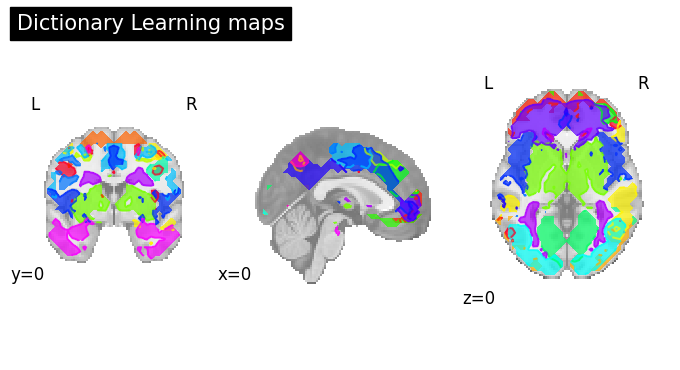

In [191]:
# Plot all ICA components together
plotting.plot_prob_atlas(components_img_dict, draw_cross=False, linewidths=None,
                         cut_coords=[0, 0, 0], title='Dictionary Learning maps');

or `plot` them separately for more detail.

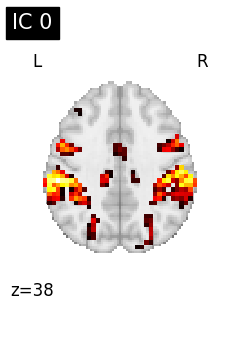

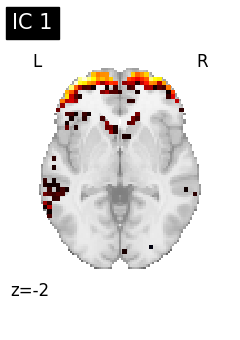

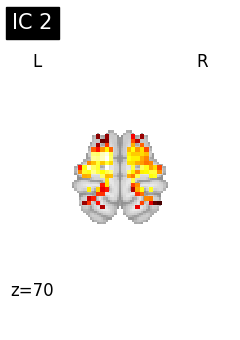

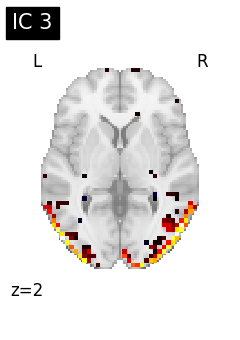

In [197]:
for i, cur_img in enumerate(iter_img(components_img_dict.slicer[..., :4])):
    plot_stat_map(
        cur_img,
        display_mode="z",
        title=f"IC {int(i)}",
        cut_coords=1,
        colorbar=False,
    )

`Maps` obtained with `dictionary leaning` are often easier to exploit as they are less `noisy` than `ICA maps`, with blobs usually better defined. Typically, `smoothing` can be lower than when doing `ICA`. While `dictionary learning` computation time is comparable to `CanICA`, obtained `atlases` have been shown to outperform `ICA` in a variety of `classification tasks`.

In addition to the `maps`, the `fit`ted `dict_learning object` can be used to calculate a `score` per `component` reflecting the estimated `explained variance` per `component`.

In [199]:
scores = dict_learning.score(development_dataset.func[:50], per_component=True)

________________________________________________________________________________
[Memory] Calling nilearn.decomposition._base._explained_variance...
_explained_variance(array([[-6.227098e-01, ...,  5.322679e+00],
       ...,
       [ 1.608246e-14, ..., -3.660237e-17]]), 
array([[0., ..., 0.],
       ...,
       [0., ..., 0.]]), per_component=True)
_____________________________________________explained_variance - 141.3s, 2.4min


These `scores` can then be visualized for inspection and more fine-grained information:

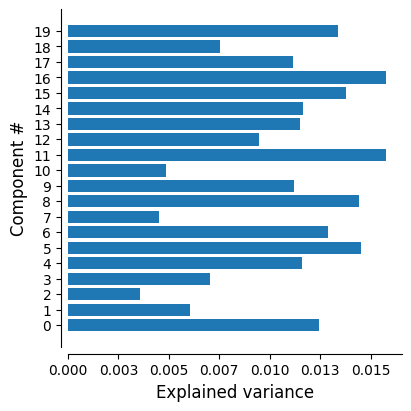

In [201]:
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(4, 4), constrained_layout=True)

positions = np.arange(len(scores))
plt.barh(positions, scores)
plt.ylabel("Component #", size=12)
plt.xlabel("Explained variance", size=12)
plt.yticks(np.arange(20))
plt.gca().xaxis.set_major_formatter(FormatStrFormatter("%.3f"))

sns.despine(offset=5)

That concludes our brief exploration of extracting `brain networks` in a `data-driven` way and also our introduction on `functional connectivity analyzes` in `nilearn`.

# Summary

In this section of the workshop we had a look at some of the functionalities `nilearn` offers for `functional connectivity analyses`, including `functional connectomes`, `seed-based maps` and `brain networks` based on `data-driven` approaches. Here are some of the key takeaways: 

- requirements:
  - `pre-processed functional images` and corresponding `confounds` are required
  - if `atlases` should be used, `nilearn` offers easy access to a lot of them  

- extracting `time-series`:
  - different `maskers` can/have to be used depending on `data` at hand
  - extraction can be modified based on `data`: `standardizing`, `detrending`, etc.)

- `functional connectomes`:
    - different options to `compute` `functional connectomes`  
          - `correlation`, `covariance`, `partial correlation`, `tangent space embedding`
    - can be applied to `single` `time-series` or `list` of `time-series`
    - plotting options: `matrix` and `graphs`

- `data-driven` `brain networks`:
    - different options for `decomposition: `CanICA`, `Dictionary Learning`
    - `components` can be extracted and further utilized